# AlphaMissense Ambiguous Variants in CYP Proteins

Demonstrates that the 6 CYP proteins studied here have a higher fraction of **ambiguous** AlphaMissense predictions than the genome-wide average reported in the AlphaMissense paper.

**Genome-wide reference (AlphaMissense paper):**
- Total missense variants: 71 million
- Likely pathogenic: 22.8 million (32%)
- Likely benign: 40.9 million (57%)
- **Ambiguous: 7.3 million (~10.3%)**

## Required input files

All paths below are relative to this notebook, i.e. `DATA_DIR = '../data'`:

| Path | Description |
|---|---|
| `AlphaMissense-Search-P*.tsv` | AlphaMissense pathogenicity score/class TSVs, one per UniProt accession. 6 CYP proteins (CYP1A2, CYP2C19, CYP2C9, CYP2D6, CYP2E1, CYP3A4) plus 6 non-CYP control proteins (ACTB, ALB, HBA1, IGHG1, INS, TNF). |
| `query-detected.sses.json` | SecStrAnnotator secondary-structure element assignments for the CYP2C9 structure (structure-chain indexed). |
| `query-sequence.json` | SecStrAnnotator query sequence metadata, used to derive the structure-to-protein coordinate offset. |
| `AF-P11712-F1-model_v6.pdb` | AlphaFold structure of CYP2C9 (UniProt P11712), used for Cα distance-to-heme-proxy calculations. |
| `masked_marginal_prob.json` | ESM-2 masked-marginal log-likelihood ratios per CYP2C9 variant, aggregated here to a per-position conservation score. |


In [1]:
import glob
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from Bio import PDB
from scipy import stats
from scipy.stats import (
    binomtest, chi2_contingency, chisquare, spearmanr, kruskal, mannwhitneyu,
)
from scipy.ndimage import gaussian_filter1d
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests

# ── Publication-quality figure defaults ───────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':         150,
    'savefig.dpi':         300,
    'font.family':         'sans-serif',
    'font.sans-serif':     ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':           11,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      12,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.fontsize':     10,
    'legend.frameon':      True,
    'legend.framealpha':   0.85,
    'legend.facecolor':    'white',
    'legend.edgecolor':    '0.8',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.8,
    'lines.linewidth':     1.2,
})

DATA_DIR = '../data'


## Genome-wide reference from the AlphaMissense paper

In [2]:
# From AlphaMissense paper (Cheng et al., Science 2023)
GENOME_TOTAL      = 71_000_000
GENOME_PATHOGENIC = 22_800_000  # 32%
GENOME_BENIGN     = 40_900_000  # 57%
GENOME_AMBIGUOUS  = GENOME_TOTAL - GENOME_PATHOGENIC - GENOME_BENIGN  # ~7.3M

GENOME_PCT = {
    'likely_pathogenic': GENOME_PATHOGENIC / GENOME_TOTAL * 100,
    'likely_benign':     GENOME_BENIGN     / GENOME_TOTAL * 100,
    'ambiguous':         GENOME_AMBIGUOUS  / GENOME_TOTAL * 100,
}

print('Genome-wide AlphaMissense class distribution (from AlphaMissensepaper):')
for cls, pct in GENOME_PCT.items():
    n = {'likely_pathogenic': GENOME_PATHOGENIC,
         'likely_benign':     GENOME_BENIGN,
         'ambiguous':         GENOME_AMBIGUOUS}[cls]
    print(f'  {cls:<22}: {n/1e6:.3f}M  ({pct:.3f}%)')

Genome-wide AlphaMissense class distribution (from AlphaMissensepaper):
  likely_pathogenic     : 22.800M  (32.113%)
  likely_benign         : 40.900M  (57.606%)
  ambiguous             : 7.300M  (10.282%)


## Load AlphaMissense predictions for all 6 CYP proteins

In [3]:
tsv_files = sorted(glob.glob(f'{DATA_DIR}/AlphaMissense-Search-P*.tsv'))
print(f'Found {len(tsv_files)} TSV files:')
for f in tsv_files:
    print(f'  {f}')

cyp_dfs = []
non_cyp_dfs = []
for f in tsv_files:
    df = pd.read_csv(f, sep='\t')
    df.columns = df.columns.str.lstrip('# ')
    if df['Gene name'].iloc[0].startswith('CYP'):
        cyp_dfs.append(df)
    else:
        non_cyp_dfs.append(df)

all_cyp = pd.concat(cyp_dfs, ignore_index=True)
print(f'\nCYP variants loaded: {len(all_cyp):,}  ({len(cyp_dfs)} proteins)')

if non_cyp_dfs:
    all_non_cyp = pd.concat(non_cyp_dfs, ignore_index=True)
    print(f'Non-CYP variants loaded: {len(all_non_cyp):,}  ({len(non_cyp_dfs)} proteins)')
    print(f'  Genes: {sorted(all_non_cyp["Gene name"].unique())}')
else:
    all_non_cyp = pd.DataFrame()
    print('No non-CYP proteins found.')

all_cyp.head()

Found 12 TSV files:
  ../data/AlphaMissense-Search-P01308.tsv
  ../data/AlphaMissense-Search-P01375.tsv
  ../data/AlphaMissense-Search-P01857.tsv
  ../data/AlphaMissense-Search-P02768.tsv
  ../data/AlphaMissense-Search-P05177.tsv
  ../data/AlphaMissense-Search-P05181.tsv
  ../data/AlphaMissense-Search-P08684.tsv
  ../data/AlphaMissense-Search-P10635.tsv
  ../data/AlphaMissense-Search-P11712.tsv
  ../data/AlphaMissense-Search-P33261.tsv
  ../data/AlphaMissense-Search-P60709.tsv
  ../data/AlphaMissense-Search-P69905.tsv

CYP variants loaded: 56,677  (6 proteins)
Non-CYP variants loaded: 34,067  (6 proteins)
  Genes: ['ACTB', 'ALB', 'HBA1', 'IGHG1', 'INS', 'TNF']


,Uniprot ACC,Entry name,Gene name,Ensemble id,protein variant,is_snv,a.a.1,position,a.a.2,pathogenicity score,pathogenicity class,REVEL pathogenicity score,REVEL pathogenicity class
0,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Cys,NaN,A,2,C,0.2632,likely_benign,NaN,NaN
1,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Asp,NaN,A,2,D,0.1088,likely_benign,NaN,NaN
2,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Glu,y,A,2,E,0.1093,likely_benign,NaN,NaN
3,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Phe,NaN,A,2,F,0.1394,likely_benign,NaN,NaN
4,P05177,CP1A2_HUMAN,CYP1A2,ENST00000343932.5,p.Ala2Gly,y,A,2,G,0.0861,likely_benign,NaN,NaN


## Per-protein breakdown

In [4]:
CLASS_ORDER = ['likely_benign', 'ambiguous', 'likely_pathogenic']

per_protein = (
    all_cyp
    .groupby(['Gene name', 'pathogenicity class'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASS_ORDER, fill_value=0)
)

per_protein['total'] = per_protein.sum(axis=1)
for cls in CLASS_ORDER:
    per_protein[f'{cls}_pct'] = per_protein[cls] / per_protein['total'] * 100

print('Per-protein variant counts and percentages:')
display_cols = CLASS_ORDER + ['total'] + [f'{c}_pct' for c in CLASS_ORDER]
per_protein[display_cols].round(3)

Per-protein variant counts and percentages:


pathogenicity class,likely_benign,ambiguous,likely_pathogenic,total,likely_benign_pct,ambiguous_pct,likely_pathogenic_pct
Gene name,,,,,,,
CYP1A2,4200,1781,3804,9785,42.923,18.201,38.876
CYP2C19,3474,1663,4154,9291,37.391,17.899,44.710
CYP2C9,3653,1782,3856,9291,39.318,19.180,41.503
CYP2D6,3595,1866,3963,9424,38.147,19.801,42.052
CYP2E1,2865,1582,4901,9348,30.648,16.923,52.428
CYP3A4,3415,1619,4504,9538,35.804,16.974,47.222


## Combined CYP breakdown vs genome-wide

In [5]:
cyp_counts = all_cyp['pathogenicity class'].value_counts()
cyp_total  = cyp_counts.sum()
cyp_pct    = cyp_counts / cyp_total * 100

print('Combined CYP proteins (all 6):')
for cls in CLASS_ORDER:
    n   = cyp_counts.get(cls, 0)
    pct = cyp_pct.get(cls, 0)
    gw  = GENOME_PCT[cls]
    delta = pct - gw
    print(f'  {cls:<22}: {n:>6,}  ({pct:7.3f}%)   genome-wide: {gw:.3f}%   delta: {delta:+.3f}%')

cyp_amb_pct    = cyp_pct.get('ambiguous', 0)
genome_amb_pct = GENOME_PCT['ambiguous']
print(f'\nCYP ambiguous: {cyp_amb_pct:.3f}% vs genome-wide: {genome_amb_pct:.3f}%')
print(f'=> CYP proteins have {cyp_amb_pct / genome_amb_pct:.3f}x more ambiguous variants')

Combined CYP proteins (all 6):
  likely_benign         : 21,202  ( 37.408%)   genome-wide: 57.606%   delta: -20.197%
  ambiguous             : 10,293  ( 18.161%)   genome-wide: 10.282%   delta: +7.879%
  likely_pathogenic     : 25,182  ( 44.431%)   genome-wide: 32.113%   delta: +12.318%

CYP ambiguous: 18.161% vs genome-wide: 10.282%
=> CYP proteins have 1.766x more ambiguous variants


## Statistical test: are CYP proteins enriched for ambiguous variants?

One-sided binomial test: under the null hypothesis the probability of a variant being ambiguous equals the genome-wide rate (10.3%). We test whether the CYP proteins show a significantly higher rate.

In [6]:
n_amb = int(cyp_counts.get('ambiguous', 0))
n_tot = int(cyp_total)
p0    = GENOME_AMBIGUOUS / GENOME_TOTAL  # genome-wide rate

result  = binomtest(n_amb, n_tot, p0, alternative='greater')
p_value = result.pvalue

print(f'Binomial test (one-sided, greater):')
print(f'  Observed: {n_amb}/{n_tot} ambiguous ({n_amb/n_tot*100:.3f}%)')
print(f'  Expected rate (genome-wide): {p0*100:.3f}%')
print(f'  p-value: {p_value:.3e}')
if p_value < 0.05:
    print('  => Significantly enriched for ambiguous variants (p < 0.05)')
else:
    print('  => Not significant at p < 0.05')

Binomial test (one-sided, greater):
  Observed: 10293/56677 ambiguous (18.161%)
  Expected rate (genome-wide): 10.282%
  p-value: 0.000e+00
  => Significantly enriched for ambiguous variants (p < 0.05)


## Visualization 1: stacked bar — per-protein vs genome-wide

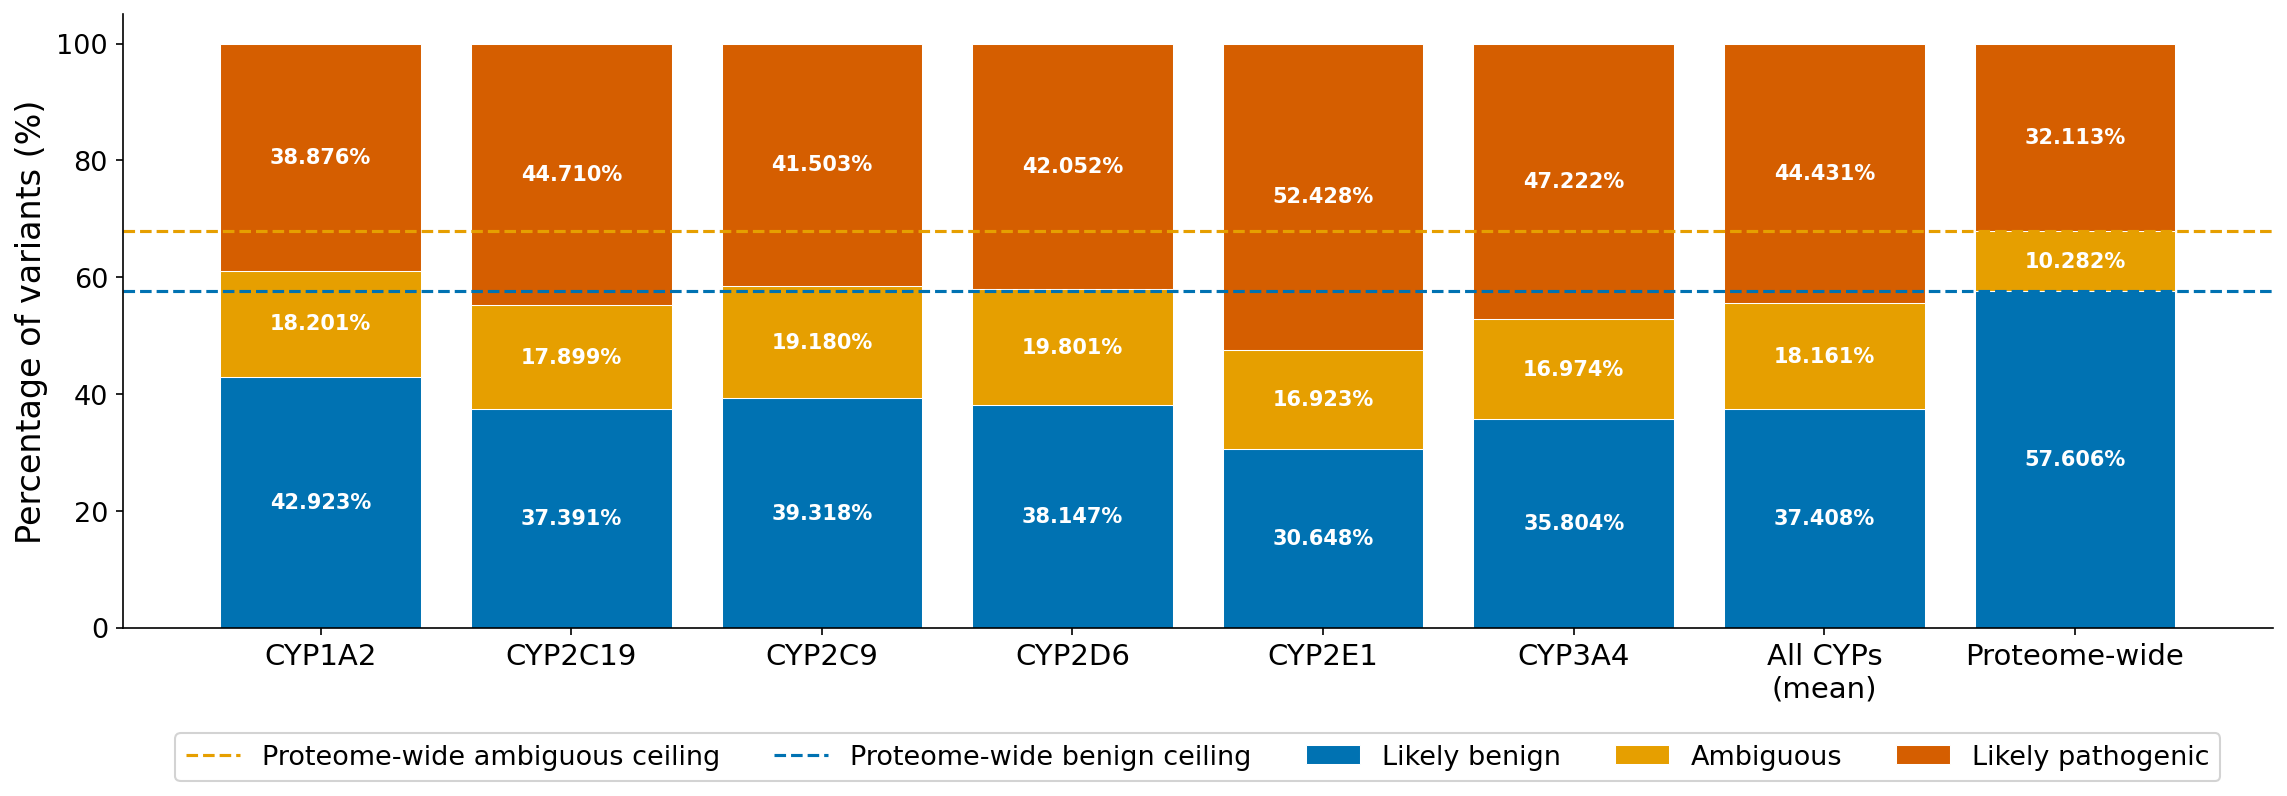

In [7]:
PALETTE = {
    'likely_benign': '#0072B2',
    'ambiguous': '#E69F00',
    'likely_pathogenic': '#D55E00',
}

# Build percentage dataframe: one row per protein + 'All CYPs' + 'Genome-wide'
rows = []
for gene, row in per_protein.iterrows():
    rows.append({
        'label': gene,
        **{cls: row[f'{cls}_pct'] for cls in CLASS_ORDER}
    })

# All CYPs combined
rows.append({
    'label': 'All CYPs\n(mean)',
    **{cls: cyp_pct.get(cls, 0) for cls in CLASS_ORDER}
})

# Genome-wide
rows.append({
    'label': 'Proteome-wide\n',
    **{cls: GENOME_PCT[cls] for cls in CLASS_ORDER}
})

plot_df = pd.DataFrame(rows).set_index('label')


def plot_stacked_class_bars(ax, plot_df, label_mode='pct'):
    """Stacked bar of AM class percentages per group, with proteome-wide reference
    lines. label_mode='pct' annotates each segment's percentage; label_mode='delta'
    annotates only the ambiguous-fraction delta vs. proteome-wide, above each bar."""
    bottoms = np.zeros(len(plot_df))
    x = np.arange(len(plot_df))

    for cls in CLASS_ORDER:
        vals = plot_df[cls].values
        ax.bar(x, vals, bottom=bottoms, color=PALETTE[cls],
               label=cls.replace('_', ' ').capitalize(), edgecolor='white', linewidth=0.5)
        if label_mode == 'pct':
            for i, (val, bot) in enumerate(zip(vals, bottoms)):
                if val > 3:
                    ax.text(i, bot + val / 2, f'{val:.3f}%',
                            ha='center', va='center', fontsize=10, color='white', fontweight='bold')
        bottoms += vals

    gw_amb = GENOME_PCT['ambiguous']
    gw_ben = GENOME_PCT['likely_benign']

    if label_mode == 'delta':
        for i, label in enumerate(plot_df.index):
            if 'Proteome-wide' in label:
                continue
            delta = plot_df.loc[label, 'ambiguous'] - gw_amb
            ax.text(i, bottoms[i] + 1.5, f'$\\Delta$ = {delta:+.2f}',
                    ha='center', va='bottom', fontsize=16, fontweight='bold')

    # Highlight the proteome-wide ambiguous / benign levels with horizontal lines
    ax.axhline(gw_ben + gw_amb, color='#E69F00', linestyle='--', linewidth=1.5,
               label='Proteome-wide ambiguous ceiling')
    ax.axhline(gw_ben, color='#0072B2', linestyle='--', linewidth=1.5,
               label='Proteome-wide benign ceiling')

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, fontsize=14)
    ax.set_ylabel('Percentage of variants (%)', fontsize=16)
    ax.tick_params(axis='y', labelsize=13)
    ax.set_ylim(0, 105)

    # Legend placed below the plot, in a single row
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fontsize=13, framealpha=0.85, ncol=len(ax.get_legend_handles_labels()[0]))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, ax = plt.subplots(figsize=(16, 6))
plot_stacked_class_bars(ax, plot_df, label_mode='pct')
fig.tight_layout(rect=[0, 0.08, 1, 1])   # reserve bottom margin for the legend
plt.show()


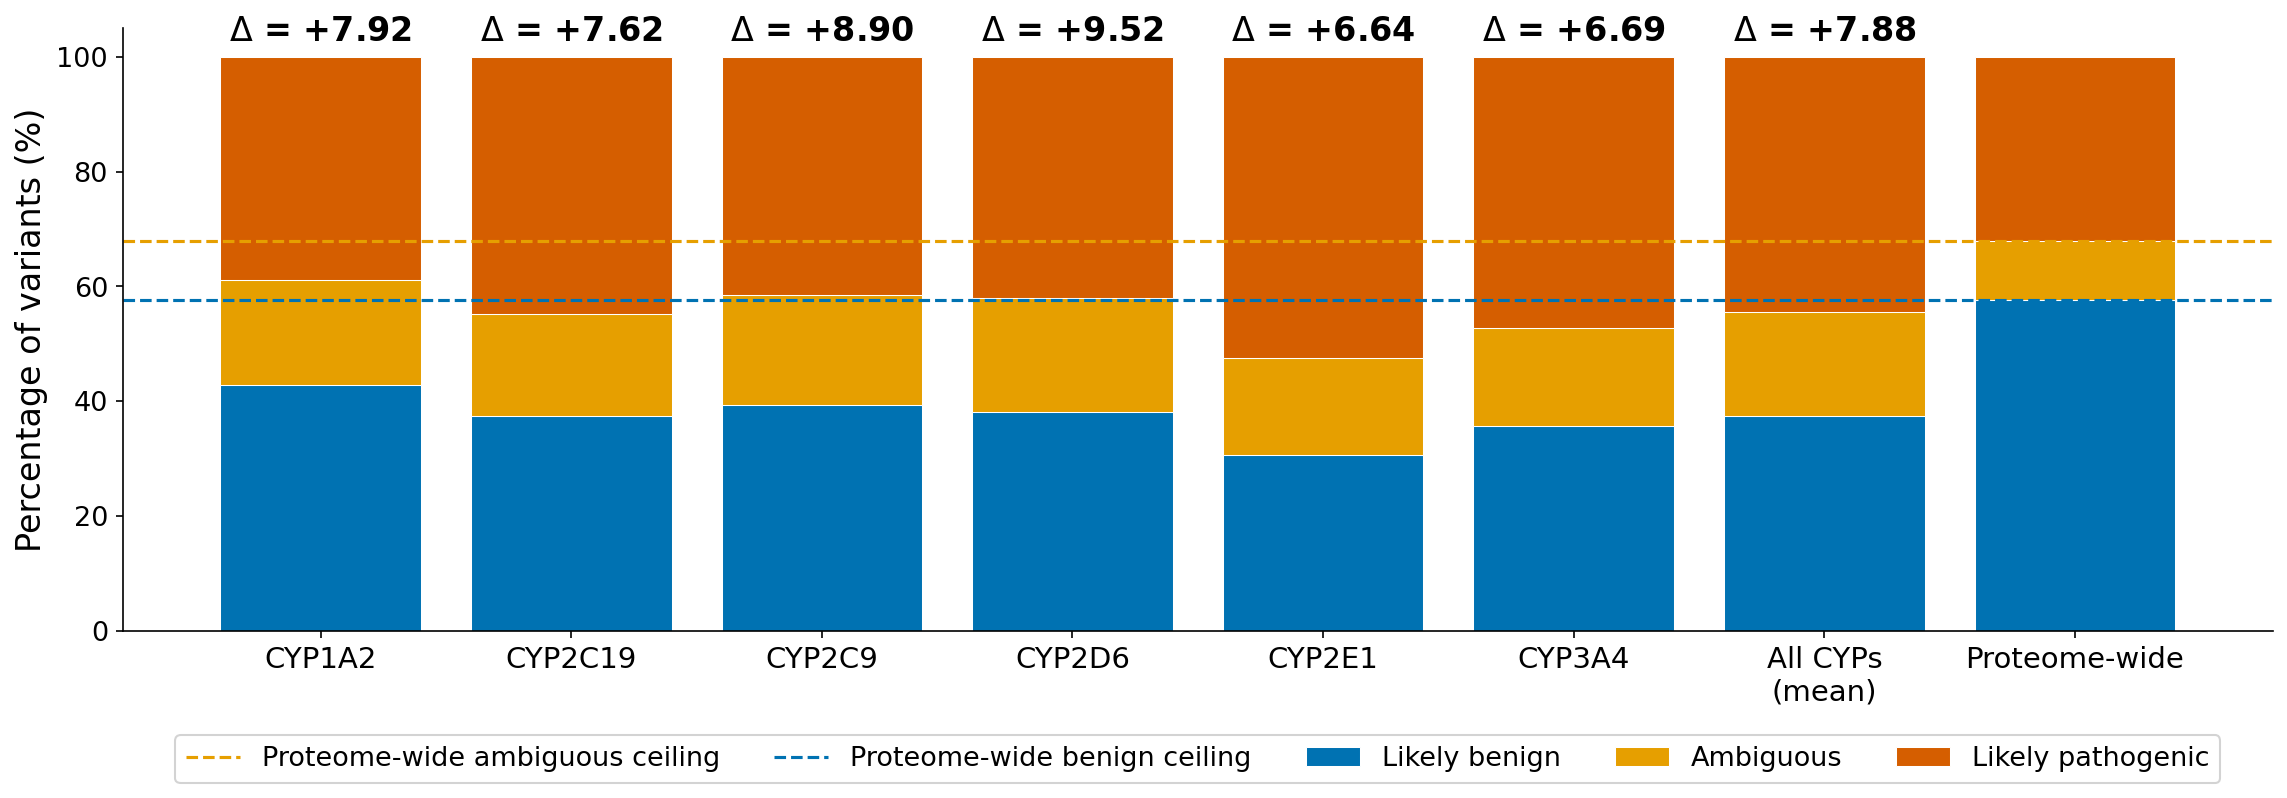

In [8]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_stacked_class_bars(ax, plot_df, label_mode='delta')
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


## Visualization 2: ambiguous fraction only — CYPs vs genome-wide

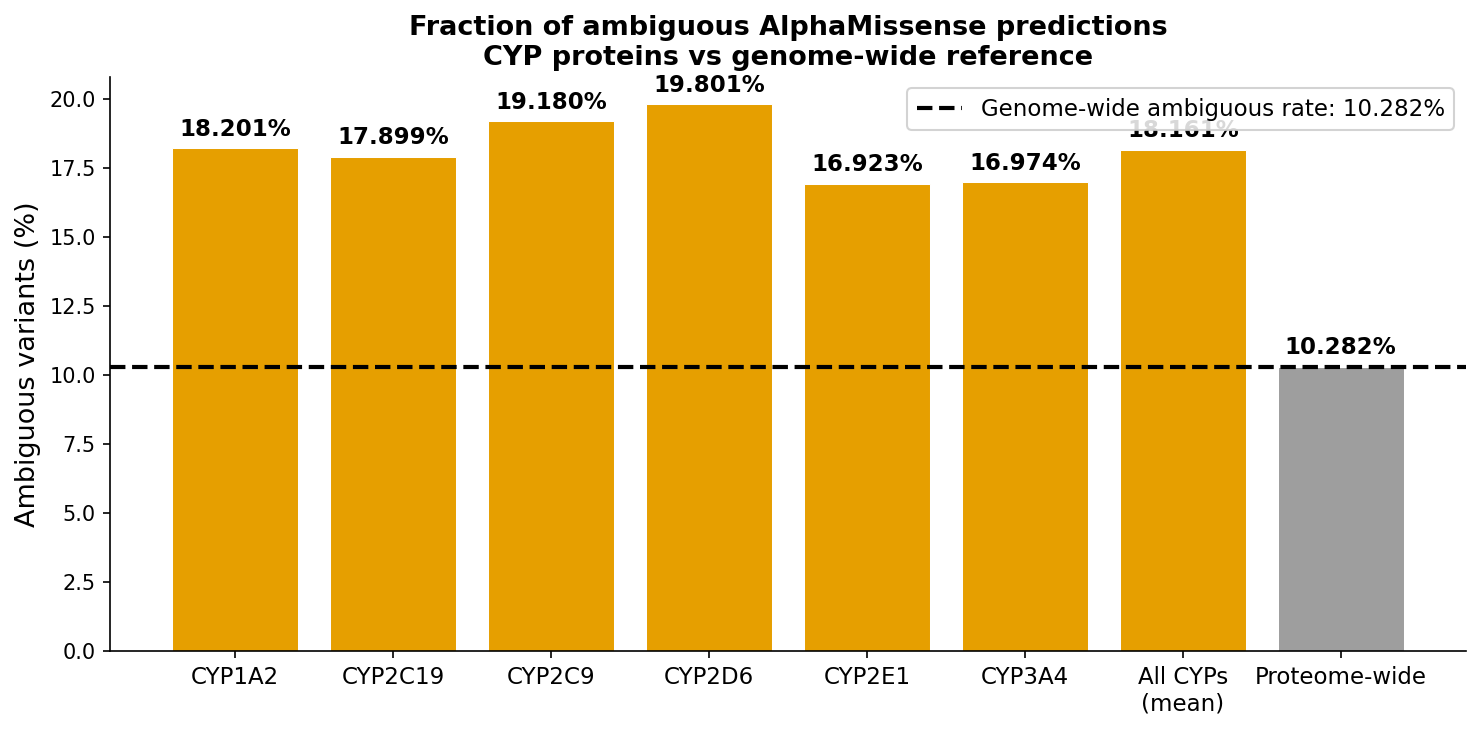

In [9]:
amb_data = plot_df[['ambiguous']].copy()

colors = ['#E69F00' if 'CYP' in idx or 'All' in idx else '#9E9E9E'
          for idx in amb_data.index]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(range(len(amb_data)), amb_data['ambiguous'].values,
              color=colors, edgecolor='white', linewidth=0.5)

# Genome-wide reference line
ax.axhline(GENOME_PCT['ambiguous'], color='black', linestyle='--', linewidth=2,
           label=f'Genome-wide ambiguous rate: {GENOME_PCT["ambiguous"]:.3f}%')

for bar, val in zip(bars, amb_data['ambiguous'].values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(amb_data)))
ax.set_xticklabels(amb_data.index, fontsize=11)
ax.set_ylabel('Ambiguous variants (%)', fontsize=13)
ax.set_title('Fraction of ambiguous AlphaMissense predictions\nCYP proteins vs genome-wide reference',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Summary table

In [ ]:
summary = plot_df.copy().round(3)
summary.columns = [c.replace('_', ' ').title() for c in summary.columns]
summary['Total Variants'] = (
    per_protein['total'].tolist()
    + [int(cyp_total)]
    + [GENOME_TOTAL]
)

# Highlight the ambiguous column
print('AlphaMissense class distribution summary (%):')
print(summary.to_string())

print(f'\nKey finding:')
print(f'  All 6 CYP proteins exceed the genome-wide ambiguous rate of {GENOME_PCT["ambiguous"]:.3f}%.')
print(f'  Combined CYP ambiguous fraction: {cyp_pct.get("ambiguous",0):.3f}%')
print(f'  That is {cyp_pct.get("ambiguous",0) / GENOME_PCT["ambiguous"]:.3f}x the genome-wide rate.')

AlphaMissense class distribution summary (%):
                  Likely Benign  Ambiguous  Likely Pathogenic  Total Variants
label                                                                        
CYP1A2                   42.923     18.201             38.876            9785
CYP2C19                  37.391     17.899             44.710            9291
CYP2C9                   39.318     19.180             41.503            9291
CYP2D6                   38.147     19.801             42.052            9424
CYP2E1                   30.648     16.923             52.428            9348
CYP3A4                   35.804     16.974             47.222            9538
All CYPs\n(mean)         37.408     18.161             44.431           56677
Proteome-wide\n          57.606     10.282             32.113        71000000

Key finding:
  All 6 CYP proteins exceed the genome-wide ambiguous rate of 10.282%.
  Combined CYP ambiguous fraction: 18.161%
  That is 1.766x the genome-wide rate.


---
## Pattern analysis: what characterizes ambiguous variants?

Five complementary lenses:
1. **Positional distribution** — do ambiguous variants cluster at specific locations along the protein?
2. **Amino acid substitution enrichment** — which WT→mutant changes are hardest for AM to classify?
3. **Secondary structure enrichment** — do ambiguous variants concentrate in particular structural elements? (CYP2C9 with offset correction)
4. **Distance to the heme/active-site proxy** — are ambiguous variants closer to or farther from the active site than benign/pathogenic variants?
5. **Evolutionary conservation (ESM-2)** — do ambiguous variants sit at positions of intermediate evolutionary constraint?


### 1. Positional distribution

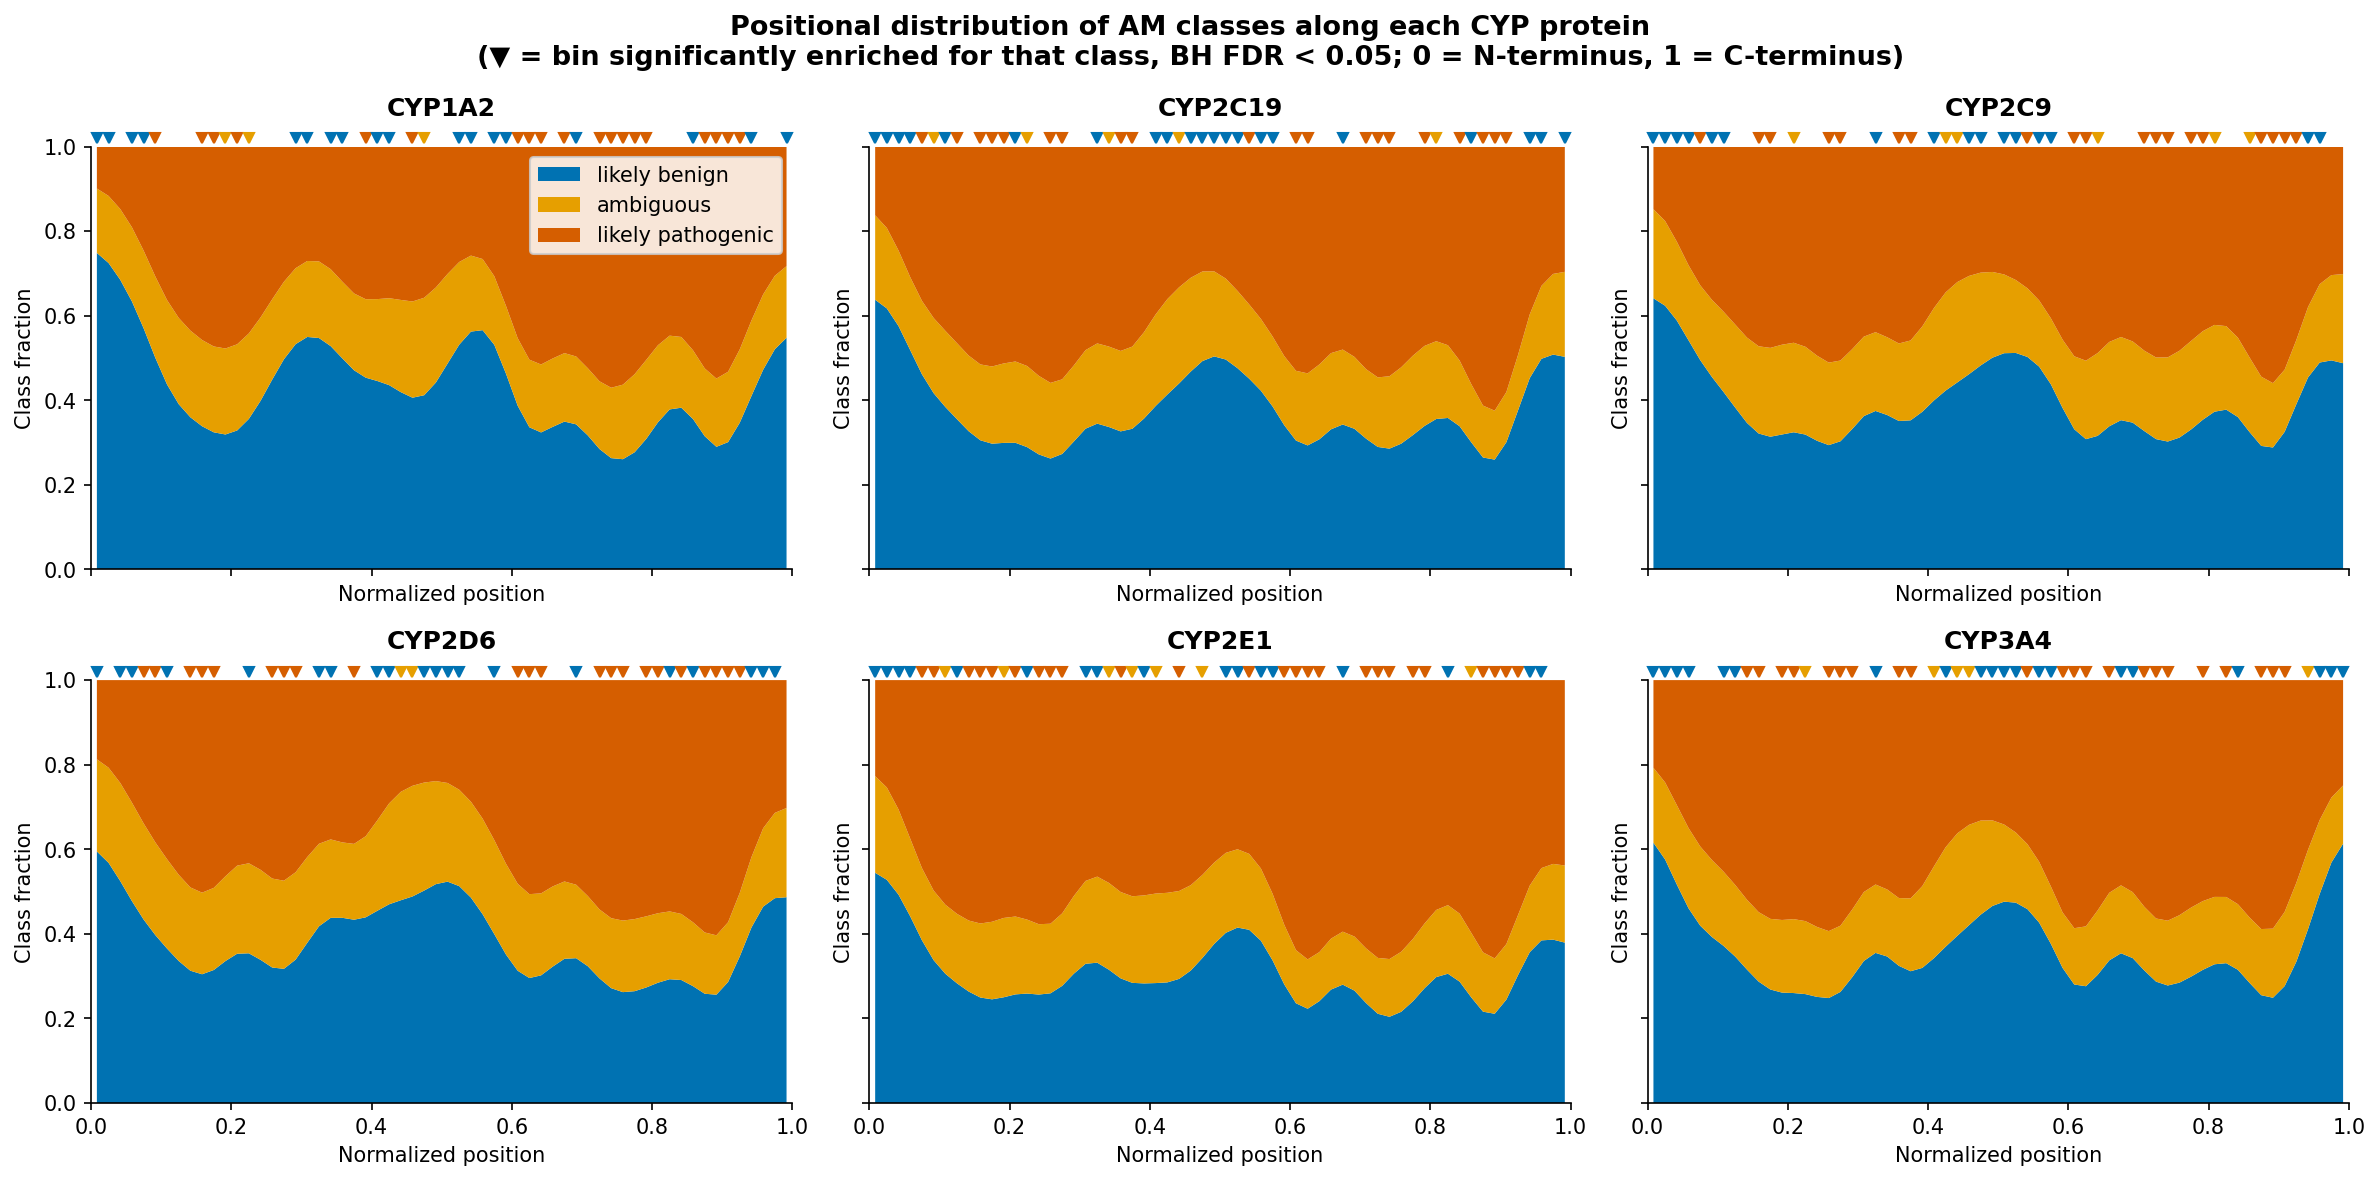

Chi-squared GOF by AM class (all CYPs, H0: proportional to overall bin density)

  Class                         chi2      df           p
  --------------------------------------------------------
  Likely benign             3334.023      59   0.000e+00
  Ambiguous                  419.030      59   1.031e-55
  Likely pathogenic         3659.941      59   0.000e+00

Bins with expected count < 5 excluded; df = valid_bins - 1.

Ambiguous fraction by protein tertile:

pathogenicity class  ambiguous
tertile                       
N-term (0-33%)          18.879
Middle (33-67%)         19.124
C-term (67-100%)        16.490

Chi-square test across tertiles: chi2 = 283.514, p = 3.894e-60


In [11]:
# Protein lengths (max observed position)
PROTEIN_LENGTHS = all_cyp.groupby('Gene name')['position'].max().to_dict()

# Normalised position: 0 = N-terminus, 1 = C-terminus
all_cyp['norm_pos'] = all_cyp['position'] / all_cyp['Gene name'].map(PROTEIN_LENGTHS)

genes = sorted(all_cyp['Gene name'].unique())
bins = np.linspace(0, 1, 61)
bin_centers = (bins[:-1] + bins[1:]) / 2


def compute_positional_sig_info(df, genes, bins, bin_centers):
    """Per-gene, per-bin chi-squared goodness-of-fit (BH-FDR corrected) of AM class
    composition against the protein-wide baseline. H0: class composition at each bin
    equals the protein-wide baseline. Bins with any expected cell count < 5 are
    excluded (chi-squared validity)."""
    sig_info = {}
    for gene in genes:
        g = df[df['Gene name'] == gene]
        expected_fracs = np.array([(g['pathogenicity class'] == cls).sum() / len(g)
                                    for cls in CLASS_ORDER])

        raw_counts = np.zeros((len(bin_centers), len(CLASS_ORDER)), dtype=int)
        for j, cls in enumerate(CLASS_ORDER):
            raw_counts[:, j], _ = np.histogram(
                g[g['pathogenicity class'] == cls]['norm_pos'], bins=bins)

        pvals = np.full(len(bin_centers), np.nan)
        for i, row in enumerate(raw_counts):
            exp = expected_fracs * row.sum()
            if (exp < 5).any():
                continue
            _, pvals[i] = chisquare(row, f_exp=exp)

        valid = ~np.isnan(pvals)
        sig_mask = np.zeros(len(bin_centers), dtype=bool)
        if valid.sum() > 0:
            _, padj, _, _ = multipletests(pvals[valid], method='fdr_bh')
            sig_mask[np.where(valid)[0][padj < 0.05]] = True

        sig_info[gene] = dict(raw_counts=raw_counts, expected_fracs=expected_fracs,
                              sig_mask=sig_mask)
    return sig_info


def class_fraction_stackplot(ax, gene_df, bins, bin_centers, capitalize_labels=False):
    """Smoothed stacked area of per-bin AM class fraction along normalized position."""
    smoothed = {}
    for cls in CLASS_ORDER:
        counts, _ = np.histogram(gene_df[gene_df['pathogenicity class'] == cls]['norm_pos'], bins=bins)
        smoothed[cls] = gaussian_filter1d(counts.astype(float), sigma=2)
    total = sum(smoothed.values())
    total[total == 0] = np.nan
    fracs = [np.nan_to_num(smoothed[cls] / total) for cls in CLASS_ORDER]

    label_fn = ((lambda c: c.replace('_', ' ').capitalize()) if capitalize_labels
                else (lambda c: c.replace('_', ' ')))
    ax.stackplot(bin_centers, fracs,
                 colors=[PALETTE[cls] for cls in CLASS_ORDER],
                 labels=[label_fn(cls) for cls in CLASS_ORDER])


def mark_significant_bins(ax, bin_centers, info):
    """Downward triangle above the plot for each significant bin, coloured by the
    class with the largest positive residual."""
    for i in np.where(info['sig_mask'])[0]:
        row = info['raw_counts'][i]
        residuals = row / row.sum() - info['expected_fracs']
        color = PALETTE[CLASS_ORDER[np.argmax(residuals)]]
        ax.plot(bin_centers[i], 1.02, 'v', color=color, ms=5,
                clip_on=False, zorder=5)


# ── Per-bin chi-squared goodness-of-fit with BH FDR correction (per protein) ─
sig_info = compute_positional_sig_info(all_cyp, genes, bins, bin_centers)

# ── Stacked area plot with significance annotations ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)

for ax, gene in zip(axes.flat, genes):
    g = all_cyp[all_cyp['Gene name'] == gene]
    class_fraction_stackplot(ax, g, bins, bin_centers)
    mark_significant_bins(ax, bin_centers, sig_info[gene])

    ax.set_title(gene, fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Normalized position', fontsize=10)
    ax.set_ylabel('Class fraction', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0, 0].legend(fontsize=10)
fig.suptitle(
    'Positional distribution of AM classes along each CYP protein\n'
    '(\u25bc = bin significantly enriched for that class, BH FDR < 0.05; '
    '0 = N-terminus, 1 = C-terminus)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Chi-squared GOF by AM class (all CYPs aggregated) ───────────────────────
# For each class: H0 = positional distribution is proportional to overall bin
# density (i.e., no positional enrichment relative to where variants fall).
# Bins with expected count < 5 excluded for chi-squared validity.

_ct_all = np.zeros((len(bin_centers), len(CLASS_ORDER)), dtype=int)
for _j, _cls in enumerate(CLASS_ORDER):
    _ct_all[:, _j], _ = np.histogram(
        all_cyp[all_cyp['pathogenicity class'] == _cls]['norm_pos'], bins=bins)
_ct_all   = _ct_all[_ct_all.sum(axis=1) > 0]
_bin_tot  = _ct_all.sum(axis=1)
_grand    = _ct_all.sum()

_cls_labels = {
    'likely_benign':     'Likely benign',
    'ambiguous':         'Ambiguous',
    'likely_pathogenic': 'Likely pathogenic',
}

print('Chi-squared GOF by AM class (all CYPs, H0: proportional to overall bin density)\n')
print(f'  {"Class":<22}  {"chi2":>10}  {"df":>6}  {"p":>10}')
print('  ' + '-' * 56)

for _j, _cls in enumerate(CLASS_ORDER):
    _obs   = _ct_all[:, _j]
    _exp   = _bin_tot * (_obs.sum() / _grand)
    _valid = _exp >= 5
    _chi2, _p = chisquare(_obs[_valid], f_exp=_exp[_valid])
    _df = int(_valid.sum()) - 1
    print(f'  {_cls_labels[_cls]:<22}  {_chi2:>10.3f}  {_df:>6}  {_p:>10.3e}')

print('\nBins with expected count < 5 excluded; df = valid_bins - 1.')

# ── Tertile breakdown (summary) ───────────────────────────────────────────────
all_cyp['tertile'] = pd.cut(all_cyp['norm_pos'], bins=[0, 1/3, 2/3, 1.0],
                             labels=['N-term (0-33%)', 'Middle (33-67%)', 'C-term (67-100%)'],
                             include_lowest=True)

tertile_ct = (all_cyp.groupby(['tertile', 'pathogenicity class'], observed=False)
                      .size().unstack(fill_value=0)
                      .reindex(columns=CLASS_ORDER))

tertile_pct = tertile_ct.div(tertile_ct.sum(axis=1), axis=0) * 100
print('\nAmbiguous fraction by protein tertile:\n')
print(tertile_pct[['ambiguous']].round(3).to_string())

chi2, p_chi, _, _ = chi2_contingency(tertile_ct.values)
print(f'\nChi-square test across tertiles: chi2 = {chi2:.3f}, p = {p_chi:.3e}')


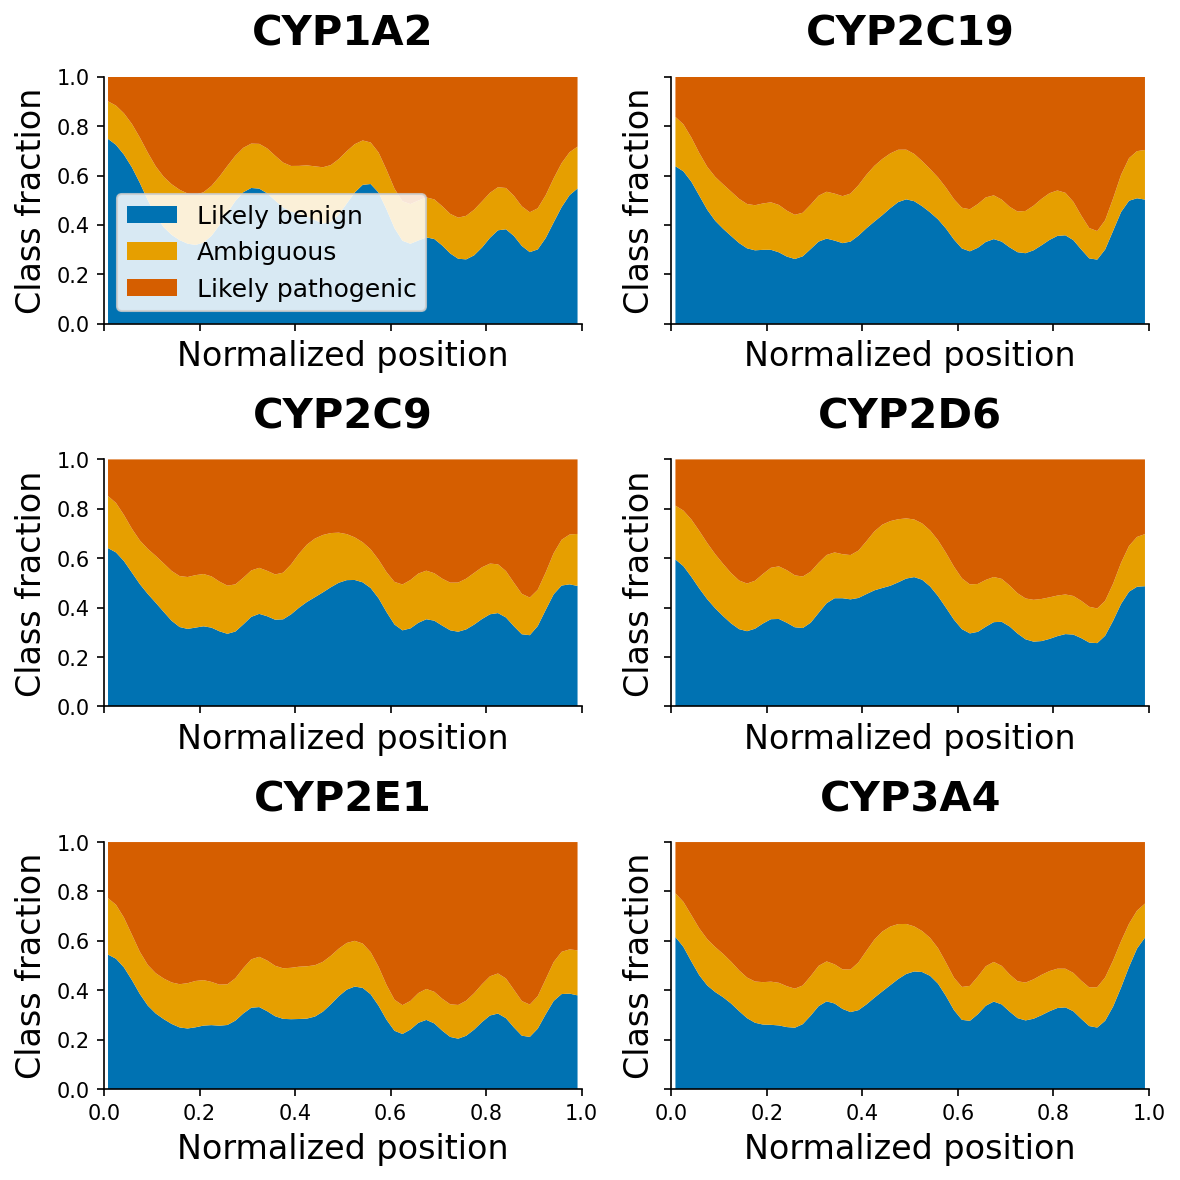

In [12]:
# ── Same figure without significance markers ─────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(8, 8), sharex=True, sharey=True)

for ax, gene in zip(axes.flat, genes):
    g = all_cyp[all_cyp['Gene name'] == gene]
    class_fraction_stackplot(ax, g, bins, bin_centers, capitalize_labels=True)

    ax.set_title(gene, fontsize=20, fontweight='bold', pad=15)
    ax.set_xlabel('Normalized position', fontsize=16)
    ax.set_ylabel('Class fraction', fontsize=16)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0, 0].legend(fontsize=12)
plt.tight_layout()
plt.show()


#### Positional distribution — non-CYP proteins (controls)

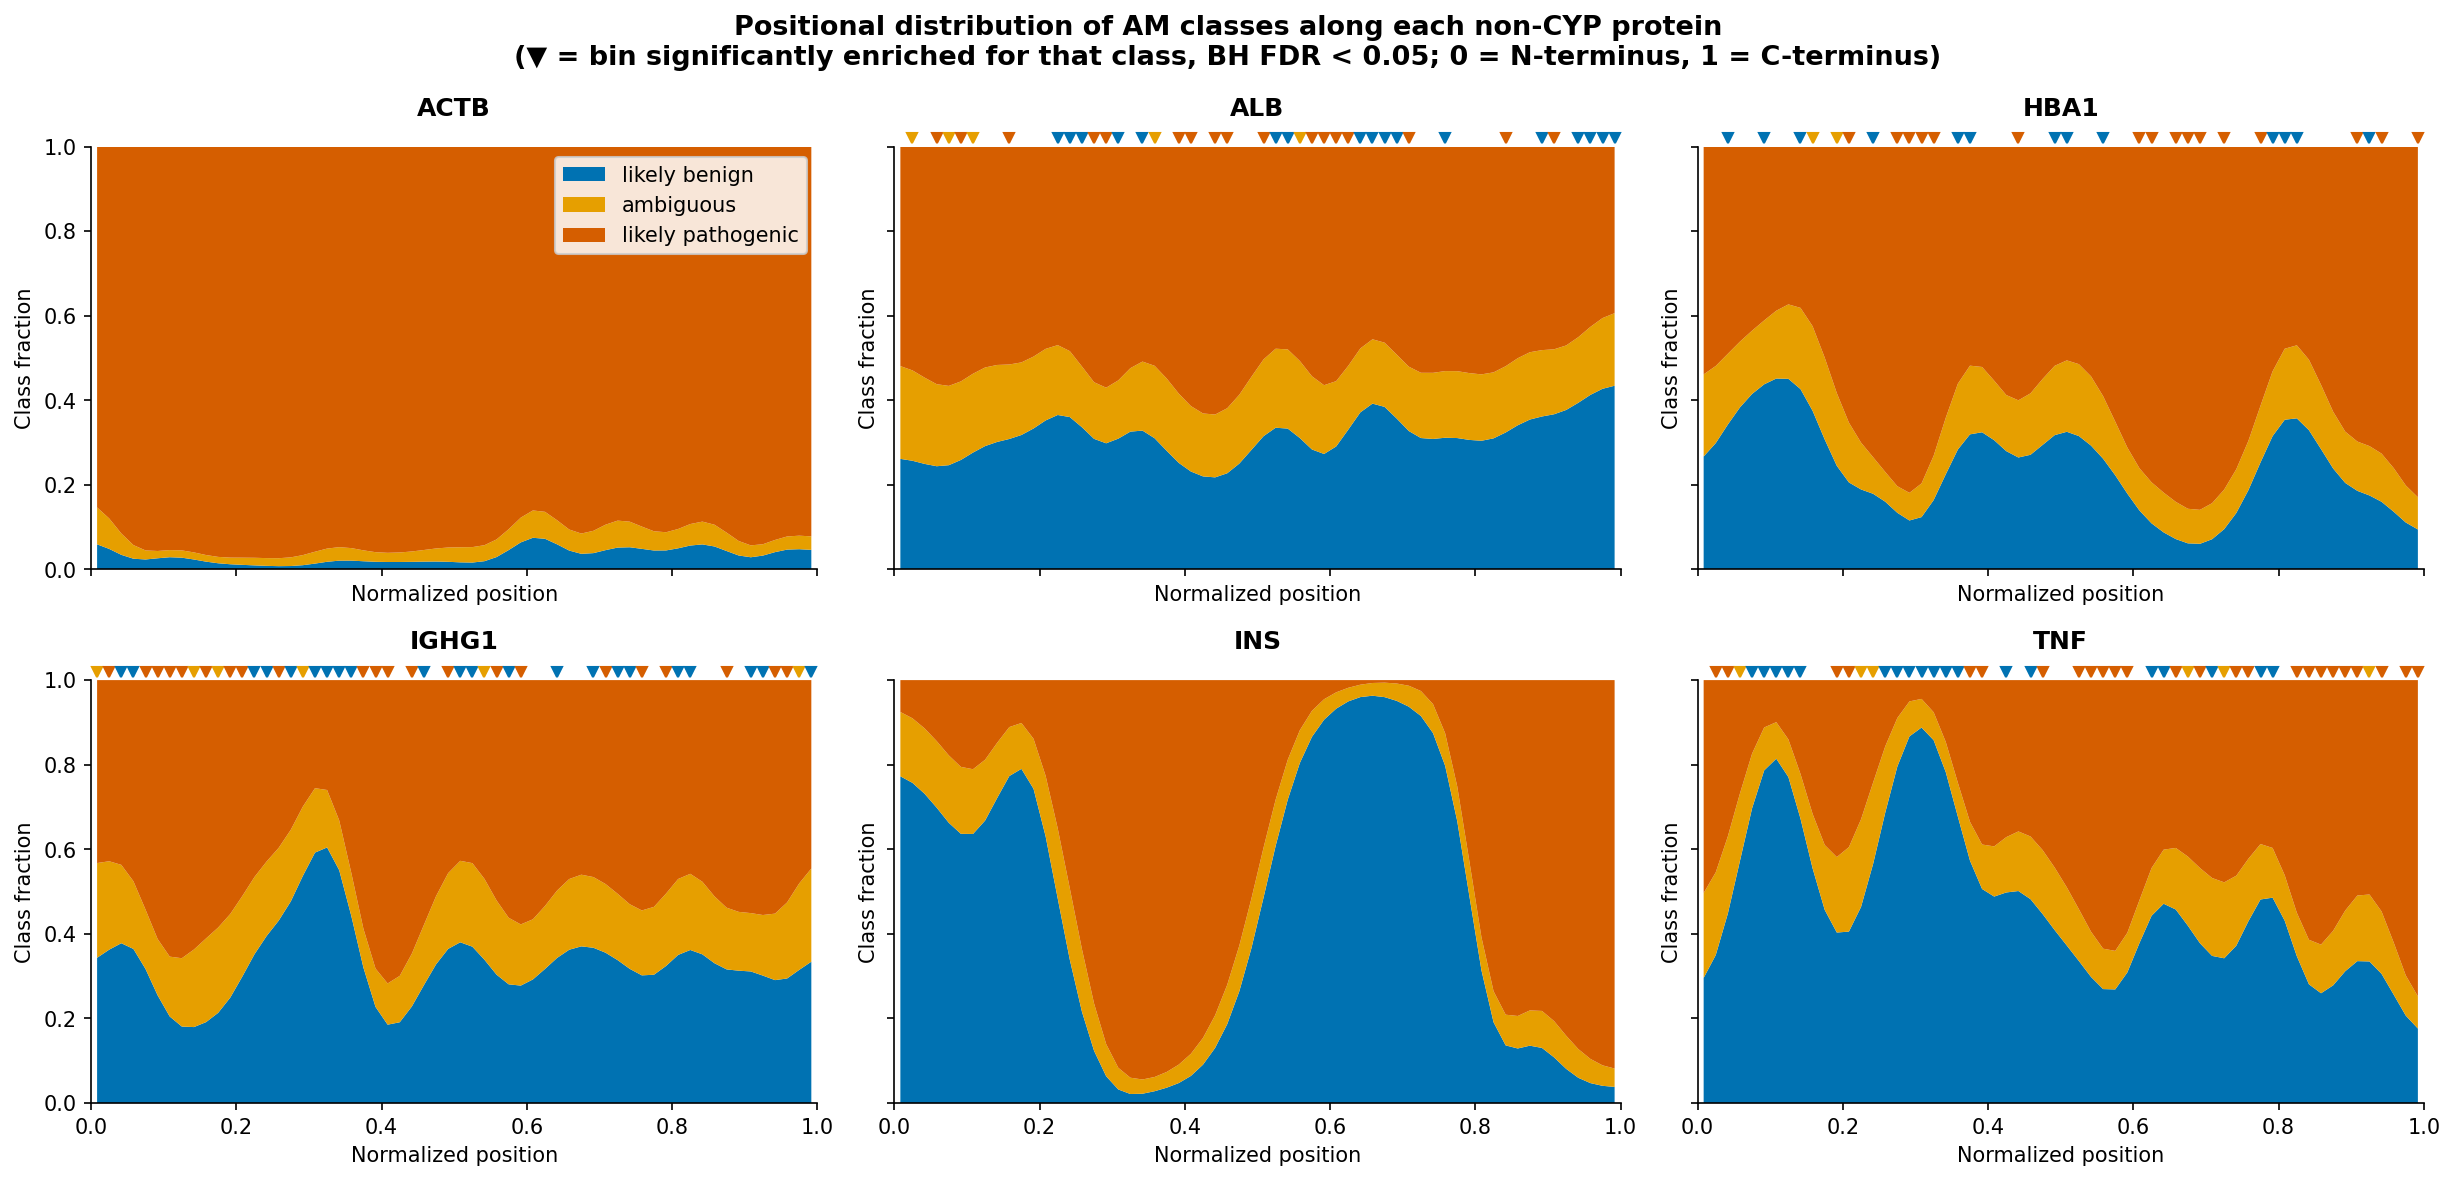

In [13]:
if all_non_cyp.empty:
    print('No non-CYP proteins loaded — skipping positional distribution plot.')
else:
    non_cyp_lengths = all_non_cyp.groupby('Gene name')['position'].max().to_dict()
    all_non_cyp['norm_pos'] = (
        all_non_cyp['position'] / all_non_cyp['Gene name'].map(non_cyp_lengths)
    )

    non_cyp_genes = sorted(all_non_cyp['Gene name'].unique())
    n_genes = len(non_cyp_genes)
    ncols = min(3, n_genes)
    nrows = math.ceil(n_genes / ncols)

    nc_bins = np.linspace(0, 1, 61)
    nc_bin_centers = (nc_bins[:-1] + nc_bins[1:]) / 2

    sig_info_nc = compute_positional_sig_info(all_non_cyp, non_cyp_genes, nc_bins, nc_bin_centers)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4),
                             sharex=True, sharey=True, squeeze=False)

    for ax, gene in zip(axes.flat, non_cyp_genes):
        g = all_non_cyp[all_non_cyp['Gene name'] == gene]
        class_fraction_stackplot(ax, g, nc_bins, nc_bin_centers)
        mark_significant_bins(ax, nc_bin_centers, sig_info_nc[gene])

        ax.set_title(gene, fontsize=12, fontweight='bold', pad=15)
        ax.set_xlabel('Normalized position', fontsize=10)
        ax.set_ylabel('Class fraction', fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 1)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Hide any unused axes
    for ax in axes.flat[n_genes:]:
        ax.set_visible(False)

    axes.flat[0].legend(fontsize=10)
    fig.suptitle(
        'Positional distribution of AM classes along each non-CYP protein\n'
        '(▼ = bin significantly enriched for that class, BH FDR < 0.05; '
        '0 = N-terminus, 1 = C-terminus)',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 2. Amino acid substitution enrichment

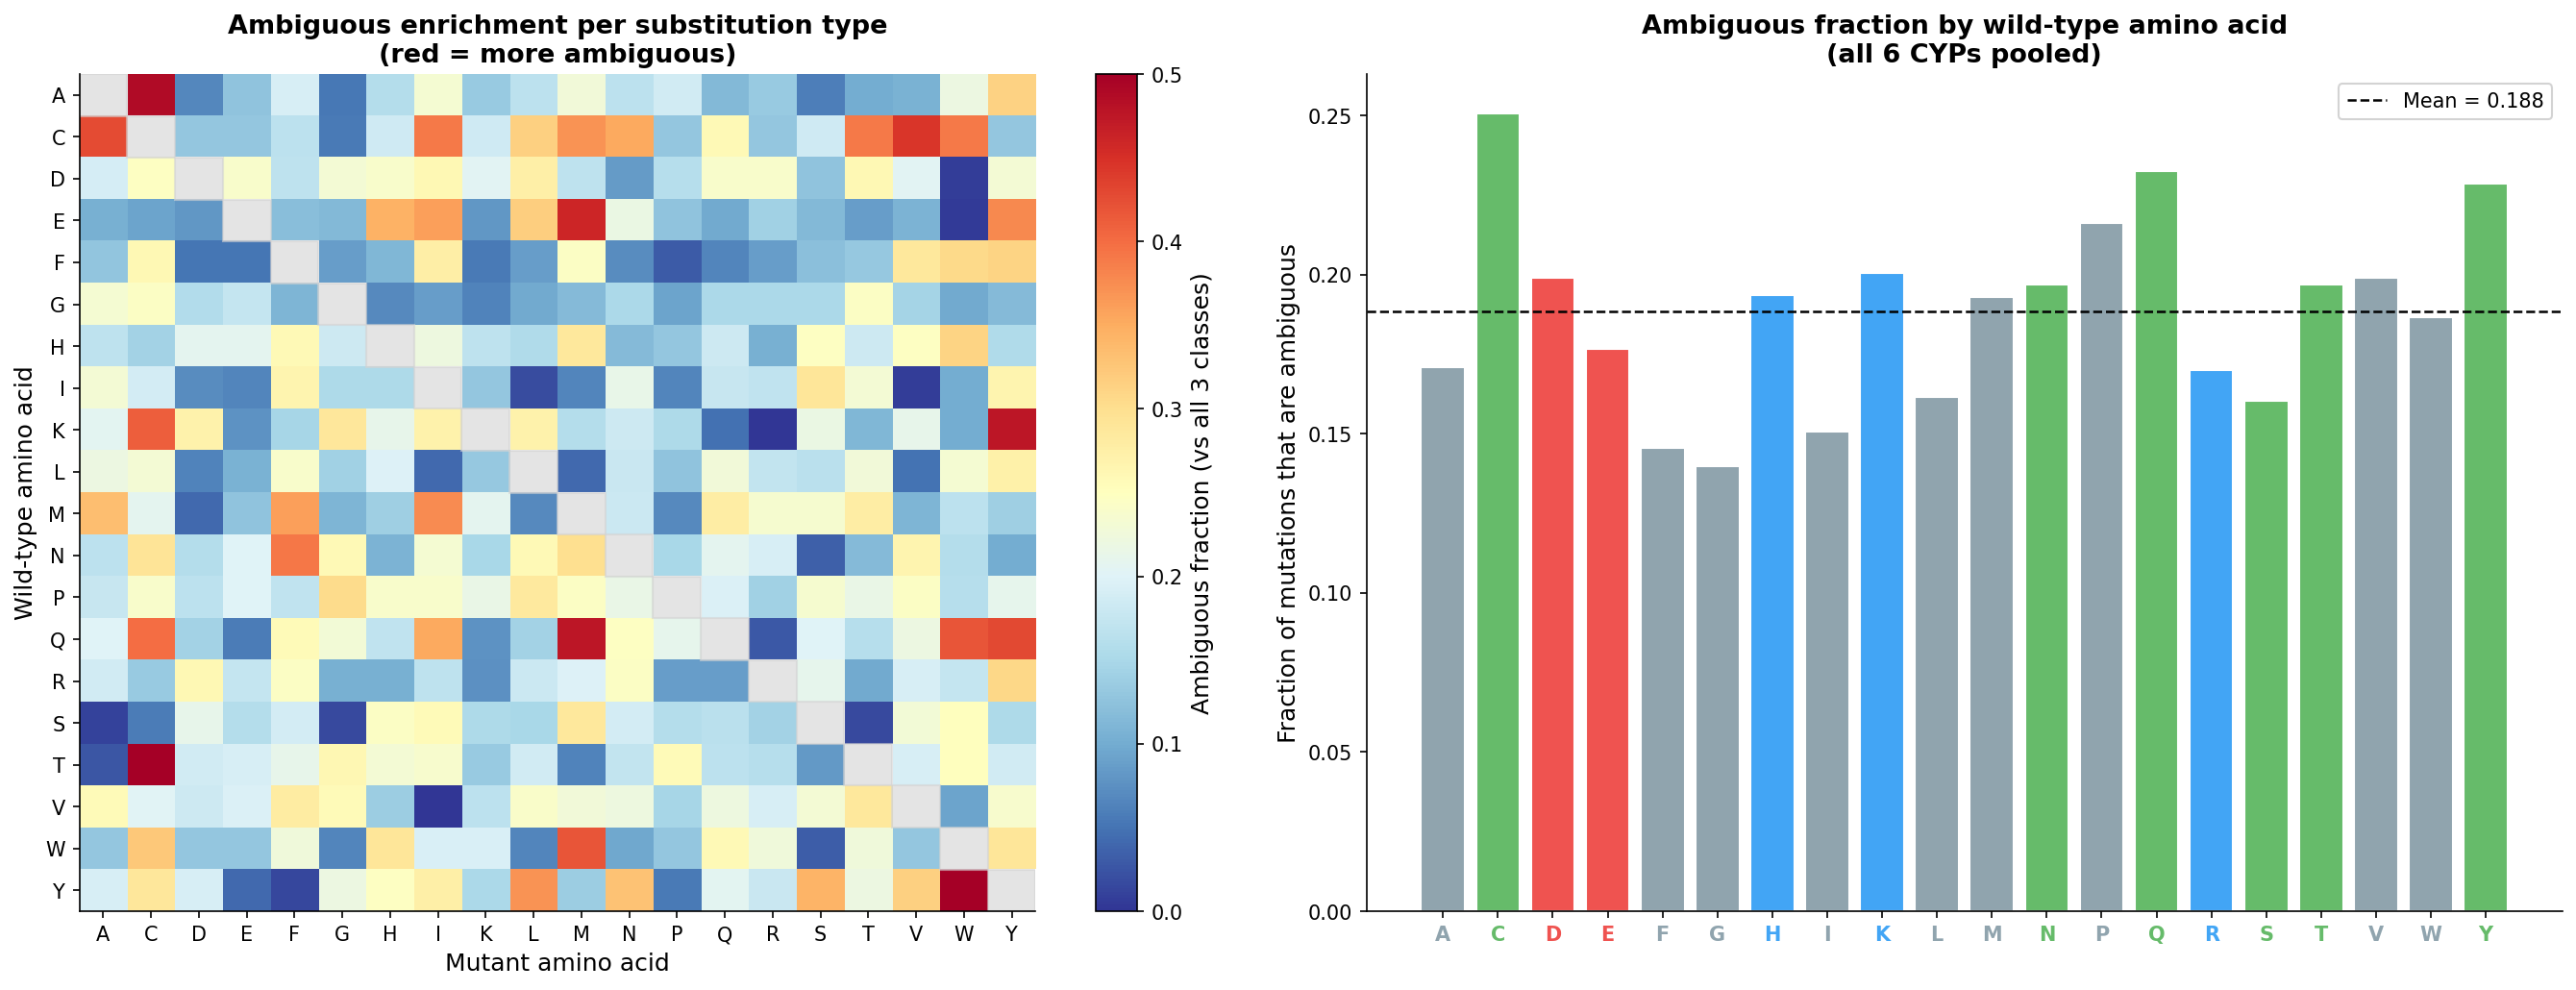

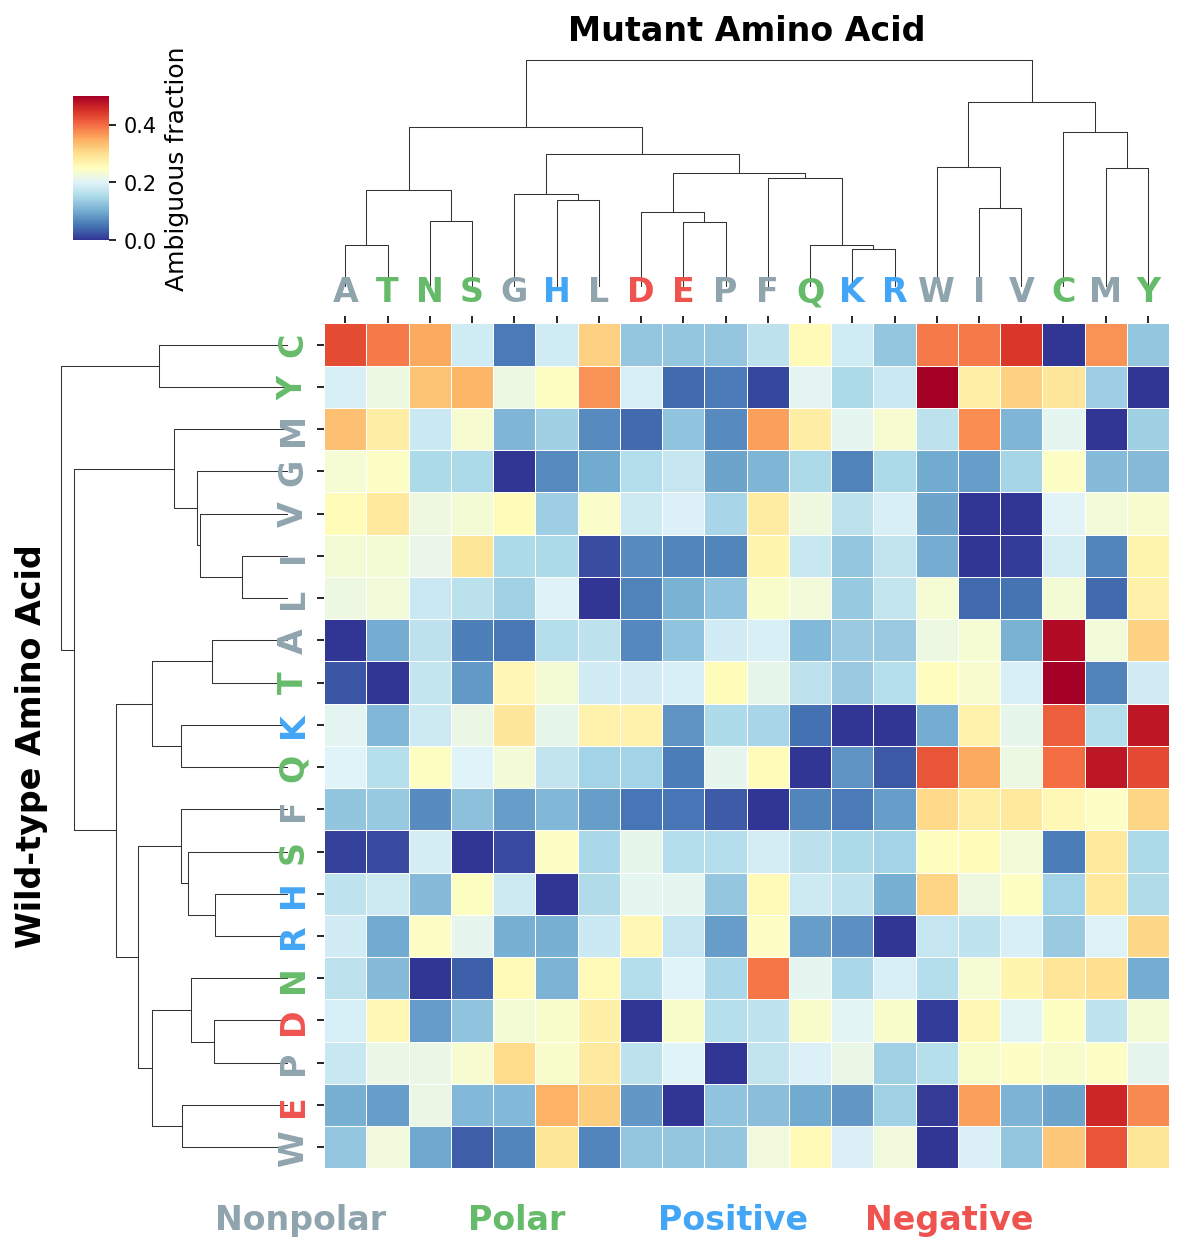

WT AA cluster order (left → right leaf):
  C  Y  M  G  V  I  L  A  T  K  Q  F  S  H  R  N  D  P  E  W

Biochemical group of each AA in cluster order:
  C: Polar
  Y: Polar
  M: Nonpolar
  G: Nonpolar
  V: Nonpolar
  I: Nonpolar
  L: Nonpolar
  A: Nonpolar
  T: Polar
  K: Positive
  Q: Polar
  F: Nonpolar
  S: Polar
  H: Positive
  R: Positive
  N: Polar
  D: Negative
  P: Nonpolar
  E: Negative
  W: Nonpolar
Ambiguous fraction by substitution type:

pathogenicity class  ambiguous
sub_type                      
Conservative            16.874
Radical                 18.713

Chi-square test (conservative vs radical): χ² = 658.319, p = 1.117e-143


In [14]:
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')

# Biochemical groups for ordering and colouring
AA_GROUPS = {
    'Nonpolar':  list('GAVLIMPFW'),
    'Polar':     list('STCYNQ'),
    'Positive':  list('RKH'),
    'Negative':  list('DE'),
}
AA_GROUP_COLOR = {'Nonpolar': '#90A4AE', 'Polar': '#66BB6A',
                  'Positive': '#42A5F5', 'Negative': '#EF5350'}

def aa_group(aa):
    for grp, members in AA_GROUPS.items():
        if aa in members:
            return grp
    return 'Other'

# ── Heatmap: ambiguous enrichment ratio per (WT, mut) pair ───────────────────
# ratio = #ambiguous / (#benign + #ambiguous + #pathogenic) for each cell
counts = {}
for cls in CLASS_ORDER:
    sub = all_cyp[all_cyp['pathogenicity class'] == cls]
    ct  = (sub.groupby(['a.a.1', 'a.a.2'])
               .size()
               .unstack(fill_value=0)
               .reindex(index=AA_ORDER, columns=AA_ORDER, fill_value=0))
    counts[cls] = ct

total_ct = sum(counts.values())
amb_ratio = counts['ambiguous'] / total_ct.replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: ambiguous enrichment ratio
ax = axes[0]
im = ax.imshow(amb_ratio.values, cmap='RdYlBu_r', vmin=0, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='Ambiguous fraction (vs all 3 classes)')
ax.set_xticks(range(len(AA_ORDER))); ax.set_xticklabels(AA_ORDER, fontsize=10)
ax.set_yticks(range(len(AA_ORDER))); ax.set_yticklabels(AA_ORDER, fontsize=10)
ax.set_xlabel('Mutant amino acid', fontsize=12)
ax.set_ylabel('Wild-type amino acid', fontsize=12)
ax.set_title('Ambiguous enrichment per substitution type\n(red = more ambiguous)', fontweight='bold')
# Mark the diagonal (synonymous, not in data) lightly
for i in range(len(AA_ORDER)):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=True,
                                color='lightgrey', zorder=2, alpha=0.6))

# Right: per-WT-AA ambiguous fraction (bar chart, coloured by biochemical group)
ax = axes[1]
wt_amb_frac = (counts['ambiguous'].sum(axis=1) /
               total_ct.sum(axis=1).replace(0, np.nan)).reindex(AA_ORDER)

bar_colors = [AA_GROUP_COLOR[aa_group(aa)] for aa in AA_ORDER]
bars = ax.bar(range(len(AA_ORDER)), wt_amb_frac.values, color=bar_colors, edgecolor='white')
ax.axhline(wt_amb_frac.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'Mean = {wt_amb_frac.mean():.3f}')
ax.set_xticks(range(len(AA_ORDER))); ax.set_xticklabels(AA_ORDER, fontsize=10)
ax.set_ylabel('Fraction of mutations that are ambiguous', fontsize=12)
ax.set_title('Ambiguous fraction by wild-type amino acid\n(all 6 CYPs pooled)', fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for label in ax.get_xticklabels():
    label.set_color(AA_GROUP_COLOR[aa_group(label.get_text())])
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# ── Hierarchical clustering of WT AAs by ambiguous substitution profile ──────
# Cluster each WT AA by its 20-dim vector of per-substitution ambiguous fractions.
# Row/column colour strip = biochemical group: do similar branches share chemistry?
amb_ratio_clust = (amb_ratio.fillna(0)          # diagonal + unobserved pairs → 0
                   .rename_axis('Wild-type amino acid', axis=0)
                   .rename_axis('Mutant amino acid', axis=1))

cg = sns.clustermap(
    amb_ratio_clust,
    method='ward',
    metric='euclidean',
    cmap='RdYlBu_r',
    vmin=0, vmax=0.5,
    figsize=(8, 8),
    linewidths=0.3,
    linecolor='white',
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=0.22,
    cbar_pos=(0.01, 0.85, 0.03, 0.12),
    cbar_kws={'label': 'Ambiguous fraction'},
)
# Pull each dendrogram away from the heatmap so tick labels fit in the gap
gap = 0.03  # figure-fraction gap between tree and heatmap
col_pos = cg.ax_col_dendrogram.get_position()
cg.ax_col_dendrogram.set_position(
    [col_pos.x0, col_pos.y0 + gap, col_pos.width, col_pos.height])
row_pos = cg.ax_row_dendrogram.get_position()
cg.ax_row_dendrogram.set_position(
    [row_pos.x0 - gap, row_pos.y0, row_pos.width, row_pos.height])

# Tick labels on the edges of the heatmap now sit in that gap
cg.ax_heatmap.xaxis.tick_top()
cg.ax_heatmap.xaxis.set_label_position('top')
cg.ax_heatmap.yaxis.tick_left()
cg.ax_heatmap.yaxis.set_label_position('left')
cg.ax_heatmap.set_xlabel('')
cg.ax_heatmap.set_ylabel('')
# Axis labels above the respective trees
cg.ax_col_dendrogram.set_title('Mutant Amino Acid', fontsize=16, pad=4)
# set_ylabel is invisible on clustermap dendrogram axes (axis rendering is off);
# use fig.text positioned relative to the row dendrogram axes bounds instead
_rp = cg.ax_row_dendrogram.get_position()
cg.fig.text(
    _rp.x0 - 0.015, _rp.y0 + _rp.height / 2,
    'Wild-type Amino Acid',
    fontsize=16, rotation=90, ha='center', va='center', fontweight='bold'
)
for label in cg.ax_heatmap.get_xticklabels():
    label.set_color(AA_GROUP_COLOR[aa_group(label.get_text())])
    label.set_fontweight('bold')
    label.set_rotation(0)
    label.set_fontsize(16)  
for label in cg.ax_heatmap.get_yticklabels():
    label.set_color(AA_GROUP_COLOR[aa_group(label.get_text())])
    label.set_fontweight('bold')
    label.set_fontsize(16)  
# Biochemical group legend: coloured text in lower figure margin — no boxes, no overlap
for i, (grp, color) in enumerate(AA_GROUP_COLOR.items()):
    cg.fig.text(
        0.2 + i * 0.18, 0.02, grp,
        color=color, fontsize=16, fontweight='bold',
        ha='center', va='bottom',
    )

plt.show()

# Print cluster order so branches can be inspected
cluster_order = [AA_ORDER[i] for i in cg.dendrogram_row.reordered_ind]
print('WT AA cluster order (left → right leaf):')
print('  ' + '  '.join(cluster_order))
print()
print('Biochemical group of each AA in cluster order:')
for aa in cluster_order:
    print(f'  {aa}: {aa_group(aa)}')


# ── Conservative vs radical substitutions ────────────────────────────────────
def substitution_type(row):
    wt, mut = row['a.a.1'], row['a.a.2']
    g_wt, g_mut = aa_group(wt), aa_group(mut)
    return 'Conservative' if g_wt == g_mut else 'Radical'

all_cyp['sub_type'] = all_cyp.apply(substitution_type, axis=1)

sub_ct = (all_cyp.groupby(['sub_type', 'pathogenicity class'])
                  .size().unstack(fill_value=0)
                  .reindex(columns=CLASS_ORDER))
sub_pct = sub_ct.div(sub_ct.sum(axis=1), axis=0) * 100

print('Ambiguous fraction by substitution type:\n')
print(sub_pct[['ambiguous']].round(3).to_string())

chi2_sub, p_sub, _, _ = chi2_contingency(sub_ct.values)
print(f'\nChi-square test (conservative vs radical): χ² = {chi2_sub:.3f}, p = {p_sub:.3e}')

### 3. Secondary structure enrichment (CYP2C9)

The SecStrAnnotator output uses structure-chain indices. The last structure position (471) corresponds to protein residue 490 (the C-terminal residue), giving an offset of 19. All SSE positions below are corrected to full protein coordinates via `protein_pos = struct_pos + 19`.

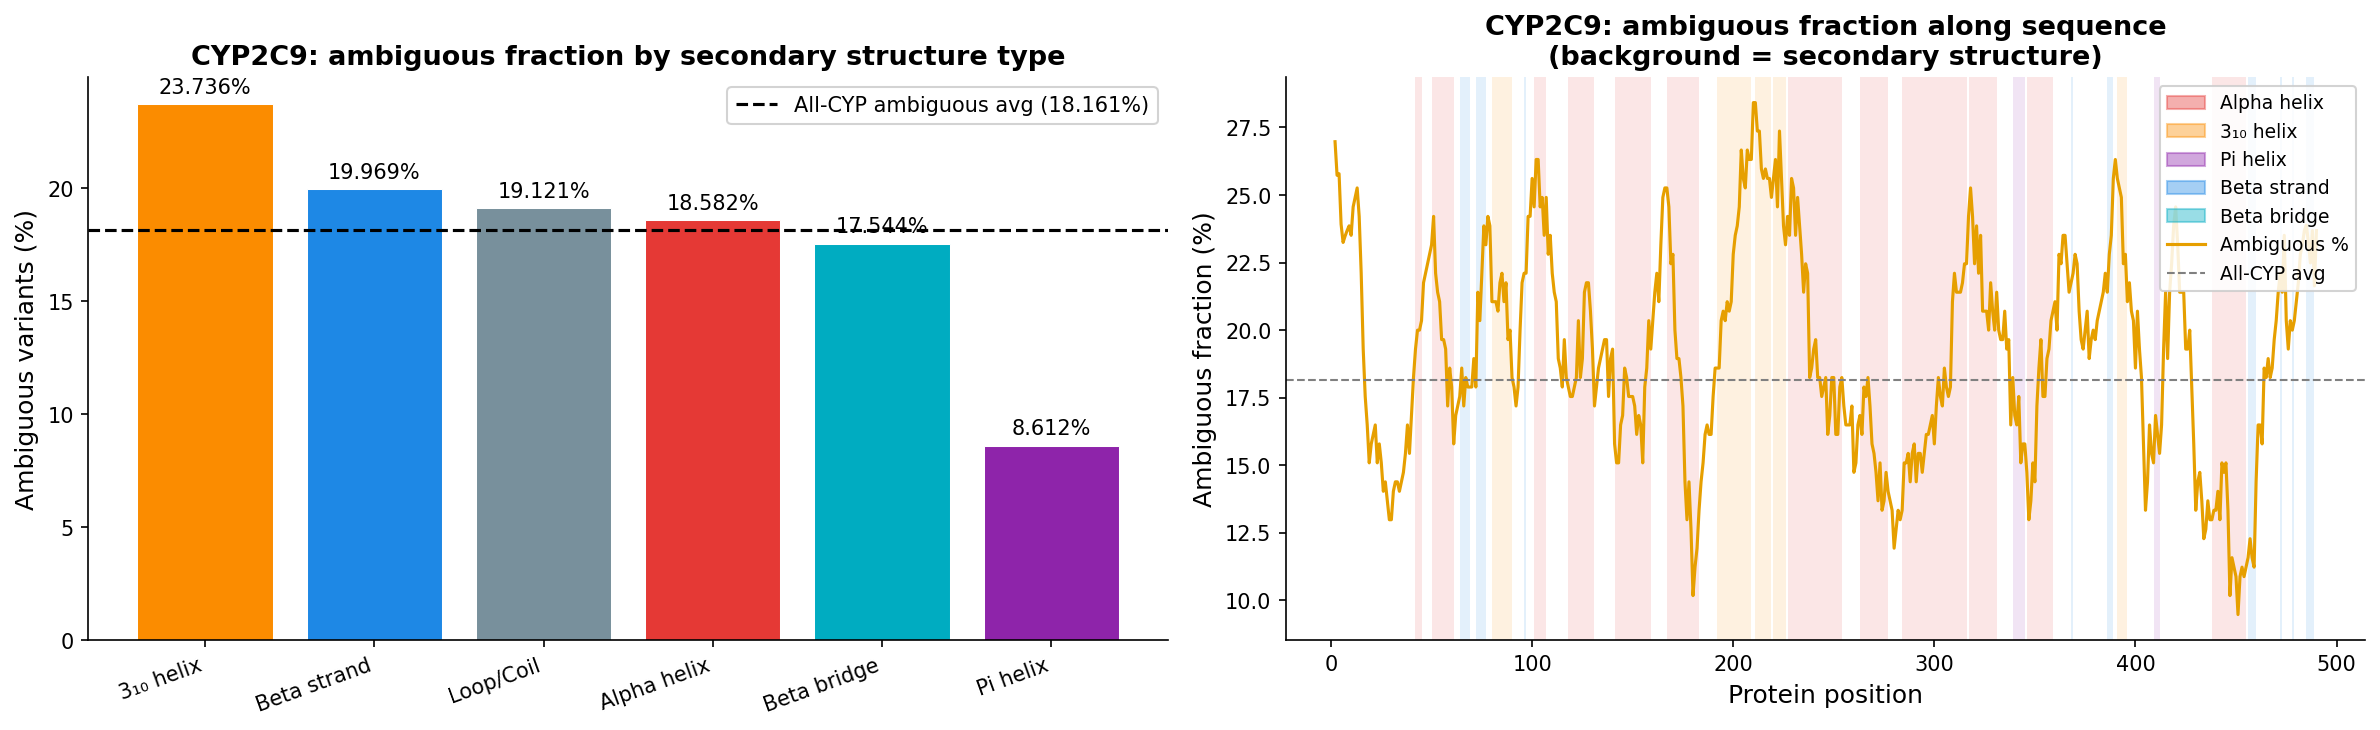

Chi-square test across secondary structure types: χ² = 169.855, p = 2.973e-31

Ambiguous fraction by SS type (CYP2C9):

pathogenicity class  ambiguous
ss_type                       
3₁₀ helix               23.736
Beta strand             19.969
Loop/Coil               19.121
Alpha helix             18.582
Beta bridge             17.544
Pi helix                 8.612

Variant counts per SS type:
ss_type
Alpha helix    3724
Loop/Coil      3572
3₁₀ helix       969
Beta strand     646
Pi helix        209
Beta bridge     171

Overall CYP2C9 baseline (all SS types combined):
pathogenicity class
likely_pathogenic    41.503
likely_benign        39.318
ambiguous            19.180


In [15]:
with open(f'{DATA_DIR}/query-detected.sses.json') as f:
    sse_data = json.load(f)['query']['secondary_structure_elements']

with open(f'{DATA_DIR}/query-sequence.json') as f:
    seq_data = json.load(f)[0]

STRUCT_OFFSET = 490 - seq_data['end']   # struct pos 471 (last in chain) → protein pos 490; offset = 19

# Canonical type labels (collapse minor helix variants to parent types)
SSE_TYPE_MAP = {
    'H': 'Alpha helix',
    'h': '3₁₀ helix',
    'G': 'Pi helix',
    'E': 'Beta strand',
    'B': 'Beta bridge',
}
SSE_COLORS = {
    'Alpha helix': '#E53935',
    '3₁₀ helix':   '#FB8C00',
    'Pi helix':    '#8E24AA',
    'Beta strand': '#1E88E5',
    'Beta bridge': '#00ACC1',
    'Loop/Coil':   '#78909C',
}

# Build position → SS-type lookup (protein coordinates)
pos_to_ss = {}
for sse in sse_data:
    ss_label = SSE_TYPE_MAP.get(sse['type'], 'Loop/Coil')
    for struct_pos in range(sse['start'], sse['end'] + 1):
        protein_pos = struct_pos + STRUCT_OFFSET
        pos_to_ss[protein_pos] = ss_label

def get_ss(protein_pos):
    return pos_to_ss.get(protein_pos, 'Loop/Coil')

# Apply to CYP2C9 variants
cyp2c9 = all_cyp[all_cyp['Gene name'] == 'CYP2C9'].copy()
cyp2c9['ss_type'] = cyp2c9['position'].apply(get_ss)

# ── Bar chart: ambiguous fraction by SS type ─────────────────────────────────
ss_ct = (cyp2c9.groupby(['ss_type', 'pathogenicity class'])
                .size().unstack(fill_value=0)
                .reindex(columns=CLASS_ORDER))
ss_ct = ss_ct[ss_ct.sum(axis=1) > 0]   # drop empty types
ss_pct = ss_ct.div(ss_ct.sum(axis=1), axis=0)  * 100
ss_pct = ss_pct.sort_values('ambiguous', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: ambiguous fraction per SS type
ax = axes[0]
bar_colors = [SSE_COLORS.get(t, '#78909C') for t in ss_pct.index]
bars = ax.bar(range(len(ss_pct)), ss_pct['ambiguous'].values,
              color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(cyp_pct.get('ambiguous', 0), color='black', linestyle='--', linewidth=1.5,
           label=f'All-CYP ambiguous avg ({cyp_pct.get("ambiguous",0):.3f}%)')
for bar, val in zip(bars, ss_pct['ambiguous'].values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.3f}%', ha='center', va='bottom', fontsize=10)
ax.set_xticks(range(len(ss_pct)))
ax.set_xticklabels(ss_pct.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Ambiguous variants (%)', fontsize=12)
ax.set_title('CYP2C9: ambiguous fraction by secondary structure type', fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: position profile with SS type colour overlay
ax = axes[1]
positions = sorted(cyp2c9['position'].unique())
window = 15

total_by_pos = cyp2c9.groupby('position').size().reindex(positions, fill_value=0)
amb_pct_smooth  = (cyp2c9[cyp2c9['pathogenicity class'] == 'ambiguous']
                   .groupby('position').size()
                   .reindex(positions, fill_value=0)
                   .div(total_by_pos.replace(0, np.nan))
                   .rolling(window, center=True, min_periods=1).mean() * 100)

ax.plot(positions, amb_pct_smooth.values, color='#E69F00', linewidth=1.5,
        label=f'Ambiguous % (rolling avg, w={window})')
ax.axhline(cyp_pct.get('ambiguous', 0), color='grey', linestyle='--', linewidth=1,
           label=f'All-CYP avg ({cyp_pct.get("ambiguous",0):.3f}%)')

# Shade SS regions
for sse in sse_data:
    p_start = sse['start'] + STRUCT_OFFSET
    p_end   = sse['end']   + STRUCT_OFFSET
    color   = SSE_COLORS.get(SSE_TYPE_MAP.get(sse['type'], 'Loop/Coil'), '#78909C')
    ax.axvspan(p_start, p_end, alpha=0.12, color=color, linewidth=0)

# Legend for SS types
ss_patches = [mpatches.Patch(color=c, alpha=0.4, label=t)
              for t, c in SSE_COLORS.items() if t != 'Loop/Coil']
ax.legend(handles=ss_patches + [
    plt.Line2D([0], [0], color='#E69F00', linewidth=1.5, label='Ambiguous %'),
    plt.Line2D([0], [0], color='grey',   linewidth=1,   linestyle='--', label='All-CYP avg'),
], fontsize=9, loc='upper right')

ax.set_xlabel('Protein position', fontsize=12)
ax.set_ylabel('Ambiguous fraction (%)', fontsize=12)
ax.set_title('CYP2C9: ambiguous fraction along sequence\n(background = secondary structure)', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Chi-square test across SS types ──────────────────────────────────────────
chi2_ss, p_ss, _, _ = chi2_contingency(ss_ct.values)
print(f'Chi-square test across secondary structure types: χ² = {chi2_ss:.3f}, p = {p_ss:.3e}\n')
print('Ambiguous fraction by SS type (CYP2C9):\n')
print(ss_pct[['ambiguous']].round(3).to_string())
print(f'\nVariant counts per SS type:')
print(ss_ct.sum(axis=1).sort_values(ascending=False).to_string())

# ── Overall CYP2C9 baseline (all SS types combined) ──────────────────────────
cyp2c9_overall_pct = cyp2c9['pathogenicity class'].value_counts(normalize=True) * 100
print(f'\nOverall CYP2C9 baseline (all SS types combined):')
print(cyp2c9_overall_pct.round(3).to_string())

#### Secondary structure enrichment: all three AM classes

Same analysis repeated for all classes. The grouped bar shows the fraction of each class within each SS type; dashed lines mark the overall per-class average across CYP2C9. A bar above its dashed line means that SS type is enriched for that class relative to the protein-wide baseline.

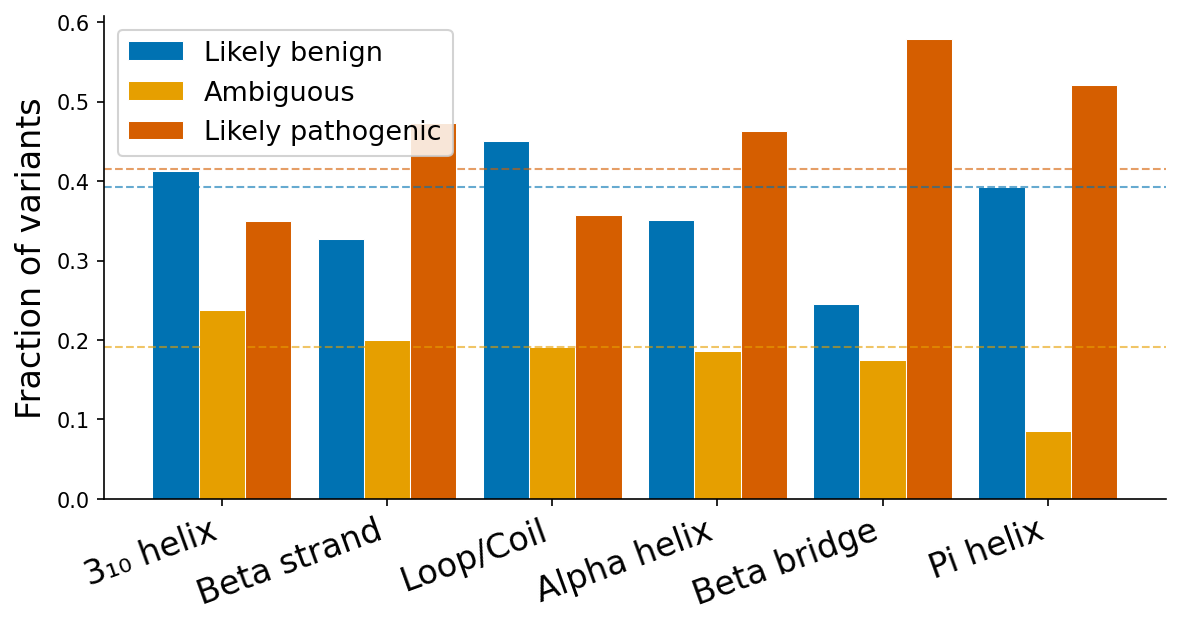

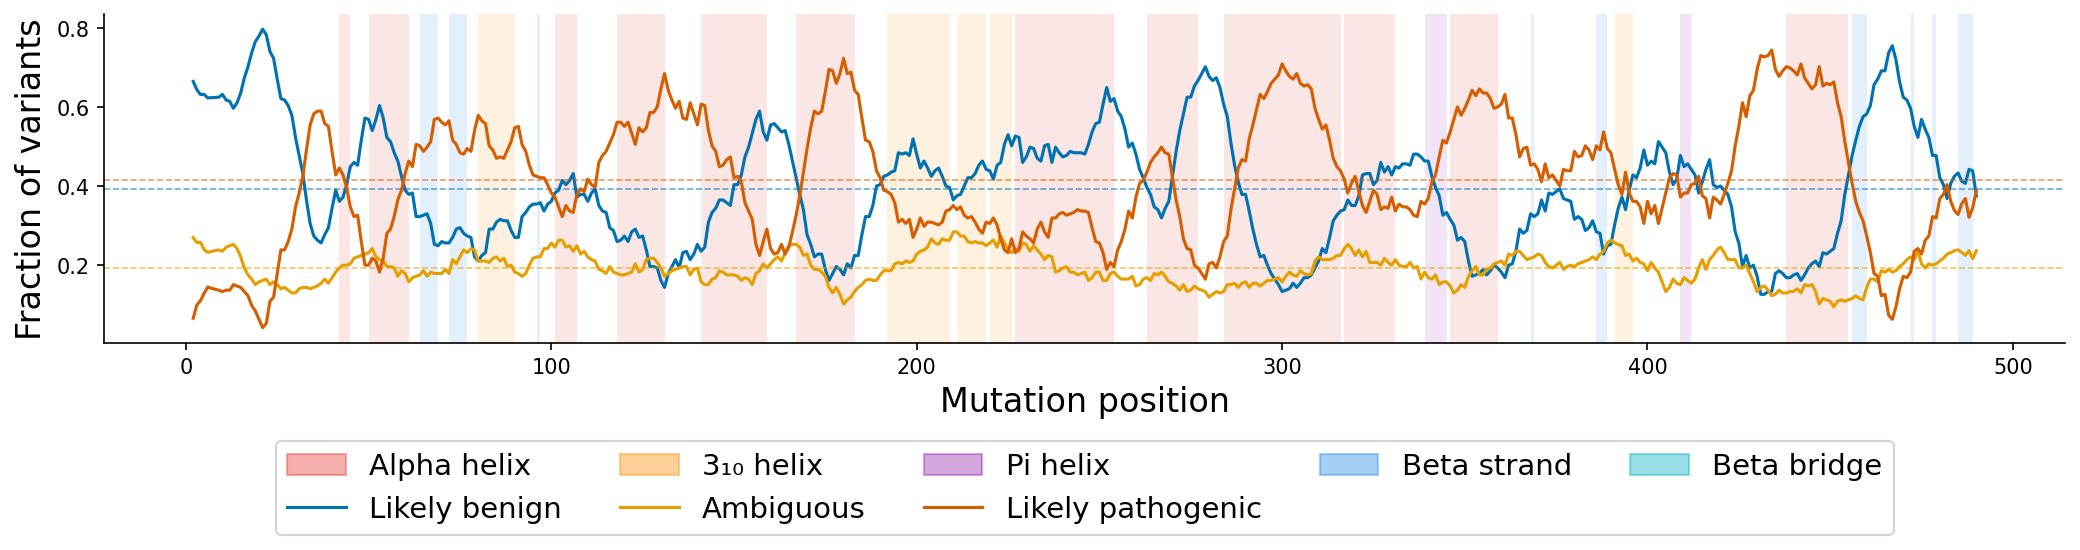

Deviation from overall class average by SS type (fraction):

pathogenicity class  likely_benign  ambiguous  likely_pathogenic
ss_type                                                         
3₁₀ helix                    0.020      0.046             -0.065
Beta strand                 -0.067      0.008              0.059
Loop/Coil                    0.058     -0.001             -0.057
Alpha helix                 -0.042     -0.006              0.048
Beta bridge                 -0.148     -0.016              0.164
Pi helix                    -0.001     -0.106              0.107


In [16]:
cls_labels = {
    'likely_benign':     'Likely benign',
    'ambiguous':         'Ambiguous',
    'likely_pathogenic': 'Likely pathogenic',
}

overall_fracs = {
    cls: cyp2c9['pathogenicity class'].value_counts(normalize=True).get(cls, 0)
    for cls in CLASS_ORDER
}

# ── Figure 1: grouped bar — all three classes per SS type ────────────────────
fig1, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ss_pct))
width = 0.28
for cls, offset in zip(CLASS_ORDER, [-width, 0, width]):
    ax.bar(x + offset, ss_pct[cls].values / 100, width,
           color=PALETTE[cls], label=cls_labels[cls], edgecolor='white', linewidth=0.5)
    ax.axhline(overall_fracs[cls], color=PALETTE[cls], linestyle='--', linewidth=1, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(ss_pct.index, rotation=20, ha='right', fontsize=16)
ax.set_ylabel('Fraction of variants', fontsize=16)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.legend(loc='upper left', fontsize=13)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig1.tight_layout(rect=[0, 0.14, 1, 1])   # reserve bottom margin for the legend
plt.show()

# ── Figure 2: rolling fraction along sequence for all three classes ──────────
fig2, ax = plt.subplots(figsize=(14, 5))
total_by_pos = cyp2c9.groupby('position').size().reindex(positions, fill_value=0)

for cls in CLASS_ORDER:
    cls_frac_smooth = (
        cyp2c9[cyp2c9['pathogenicity class'] == cls]
        .groupby('position').size()
        .reindex(positions, fill_value=0)
        .div(total_by_pos.replace(0, np.nan))
        .rolling(window, center=True, min_periods=1).mean()
    )
    ax.plot(positions, cls_frac_smooth.values, color=PALETTE[cls],
            linewidth=1.5, label=cls_labels[cls])
    ax.axhline(overall_fracs[cls], color=PALETTE[cls], linestyle='--', linewidth=0.8, alpha=0.6)

for sse in sse_data:
    p_start = sse['start'] + STRUCT_OFFSET
    p_end   = sse['end']   + STRUCT_OFFSET
    color   = SSE_COLORS.get(SSE_TYPE_MAP.get(sse['type'], 'Loop/Coil'), '#78909C')
    ax.axvspan(p_start, p_end, alpha=0.12, color=color, linewidth=0)

# Row 1: secondary-structure types (Alpha helix .. Beta bridge). Row 2: AM classes.
# Padded + interleaved so matplotlib's column-major legend fill lands each
# group on its own row (row 1 has 5 entries, row 2 has 3 + 2 invisible spacers).
ss_patches = [mpatches.Patch(color=c, alpha=0.4, label=t)
              for t, c in SSE_COLORS.items() if t != 'Loop/Coil']
line_handles = [plt.Line2D([0], [0], color=PALETTE[cls], linewidth=1.5, label=cls_labels[cls])
                for cls in CLASS_ORDER]
blank_handles = [mpatches.Patch(color='none', label='') for _ in range(len(ss_patches) - len(line_handles))]
line_handles_padded = line_handles + blank_handles
legend_handles = [h for pair in zip(ss_patches, line_handles_padded) for h in pair]

ax.legend(handles=legend_handles, fontsize=14,
          loc='upper center', bbox_to_anchor=(0.5, -0.3), borderaxespad=0,
          ncol=len(ss_patches))
ax.set_xlabel('Mutation position', fontsize=16)
ax.set_ylabel('Fraction of variants', fontsize=16)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig2.tight_layout(rect=[0, 0.14, 1, 1])   # reserve bottom margin for the 2-row legend
plt.show()

# ── Deviation from overall per-class average ─────────────────────────────────
print('Deviation from overall class average by SS type (fraction):\n')
deviation = ss_pct[CLASS_ORDER].div(100).subtract(pd.Series(overall_fracs))
print(deviation.round(3).to_string())

### 4. Distance to binding site (heme iron proxy) in CYP2C9

Uses the AlphaFold structure (AF-P11712-F1-model_v6.pdb). Because AlphaFold models do not include the heme cofactor, **Cys435** (the proximal axial ligand that coordinates the heme iron in all CYPs) is used as the heme-iron proxy. Distance is measured as Cα–Cα Euclidean distance in Ångströms.

**Hypothesis:** pathogenic variants cluster closer to the active site; benign variants are more peripheral; ambiguous variants occupy an intermediate zone.

In [17]:
PDB_PATH = f'{DATA_DIR}/AF-P11712-F1-model_v6.pdb'

parser = PDB.PDBParser(QUIET=True)
struct = parser.get_structure('cyp2c9', PDB_PATH)
chain = struct[0]['A']

ca_coords = {res.get_id()[1]: res['CA'].get_vector() for res in chain if 'CA' in res}
_coords = np.array([v.get_array() for v in ca_coords.values()])
_centroid = _coords.mean(axis=0)
_rg = np.sqrt(((_coords - _centroid) ** 2).sum(axis=1).mean())
_max_dist = cdist(_coords, _coords).max()

print('─' * 60)
print('CYP2C9 (AF-P11712-F1) structure summary')
print(f'  Residues with Cα     : {len(_coords)}')
print(f'  Radius of gyration   : {_rg:.3f} Å')
print(f'  Max Cα–Cα span       : {_max_dist:.3f} Å  (longest end-to-end distance)')
print()
print('Distance definition used in this section:')
print('  Cα–Cα Euclidean distance in Å between each residue and Cys435,')
print('  the proximal axial ligand of the heme iron (used as a heme-iron')
print('  proxy since the AlphaFold model does not include the heme cofactor).')
print('─' * 60)
print()

HEME_PROXY = 435
heme_vec = ca_coords[HEME_PROXY]

dist_heme = {pos: (ca_coords[pos] - heme_vec).norm() for pos in ca_coords}

cyp2c9_dist = cyp2c9.copy()
cyp2c9_dist['dist_heme'] = cyp2c9_dist['position'].map(dist_heme)

# ── Helper: binned class-fraction stacked area plot ───────────────────────────
def plot_dist_fractions(ax, df, col, xlabel, n_bins=30, sigma=1.5, show_significance=True):
    """For each distance bin, plot fraction of each AM class."""
    vals = df[col].dropna()
    bins = np.linspace(vals.min(), vals.max(), n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    counts = np.zeros((n_bins, len(CLASS_ORDER)), dtype=int)
    for j, cls in enumerate(CLASS_ORDER):
        counts[:, j], _ = np.histogram(
            df.loc[df['pathogenicity class'] == cls, col].dropna(), bins=bins)

    bin_totals = counts.sum(axis=1)
    mask = bin_totals > 0
    fracs = np.where(mask[:, None], counts / np.where(bin_totals[:, None] > 0, bin_totals[:, None], 1), np.nan)

    # Gaussian smooth
    smooth = np.zeros_like(fracs)
    for j in range(len(CLASS_ORDER)):
        col_vals = fracs[:, j].copy()
        col_vals[~mask] = 0
        smooth[:, j] = gaussian_filter1d(col_vals.astype(float), sigma=sigma)
    # renormalize after smoothing
    row_sums = smooth.sum(axis=1, keepdims=True)
    smooth = np.where(row_sums > 0, smooth / row_sums, 1 / len(CLASS_ORDER))

    ax.stackplot(
        bin_centers, *[smooth[:, j] for j in range(len(CLASS_ORDER))],
        labels=CLASS_ORDER,
        colors=[PALETTE[c] for c in CLASS_ORDER],
        alpha=0.85,
    )
    ax.set_xlim(bin_centers[0], bin_centers[-1])
    ax.set_ylim(0, 1)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Fraction of variants', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if not show_significance:
        return bin_centers, counts, None, None

    # Chi-squared goodness-of-fit per bin + BH correction
    expected_fracs = np.array([(df['pathogenicity class'] == cls).sum() / len(df)
                                for cls in CLASS_ORDER])
    pvals = np.full(n_bins, np.nan)
    for i, row in enumerate(counts):
        if not mask[i]:
            continue
        exp = expected_fracs * row.sum()
        if (exp < 5).any():
            continue
        _, pvals[i] = chisquare(row, f_exp=exp)
    valid = ~np.isnan(pvals)
    sig_mask = np.zeros(n_bins, dtype=bool)
    if valid.sum() > 0:
        _, padj, _, _ = multipletests(pvals[valid], method='fdr_bh')
        sig_mask[np.where(valid)[0][padj < 0.05]] = True

    for i in np.where(sig_mask)[0]:
        row = counts[i]
        residuals = row / row.sum() - expected_fracs
        color = PALETTE[CLASS_ORDER[np.argmax(residuals)]]
        ax.plot(bin_centers[i], 1.02, 'v', color=color, ms=5,
                clip_on=False, zorder=5)

    return bin_centers, counts, pvals, sig_mask


────────────────────────────────────────────────────────────
CYP2C9 (AF-P11712-F1) structure summary
  Residues with Cα     : 490
  Radius of gyration   : 23.834 Å
  Max Cα–Cα span       : 89.077 Å  (longest end-to-end distance)

Distance definition used in this section:
  Cα–Cα Euclidean distance in Å between each residue and Cys435,
  the proximal axial ligand of the heme iron (used as a heme-iron
  proxy since the AlphaFold model does not include the heme cofactor).
────────────────────────────────────────────────────────────



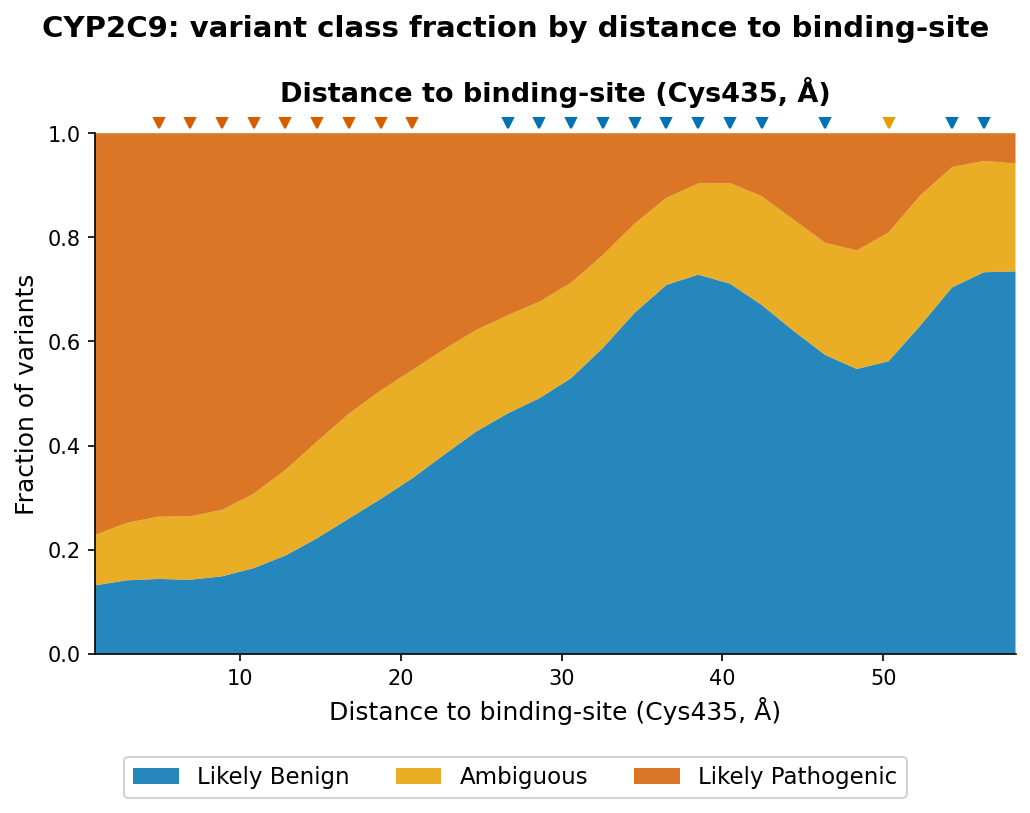

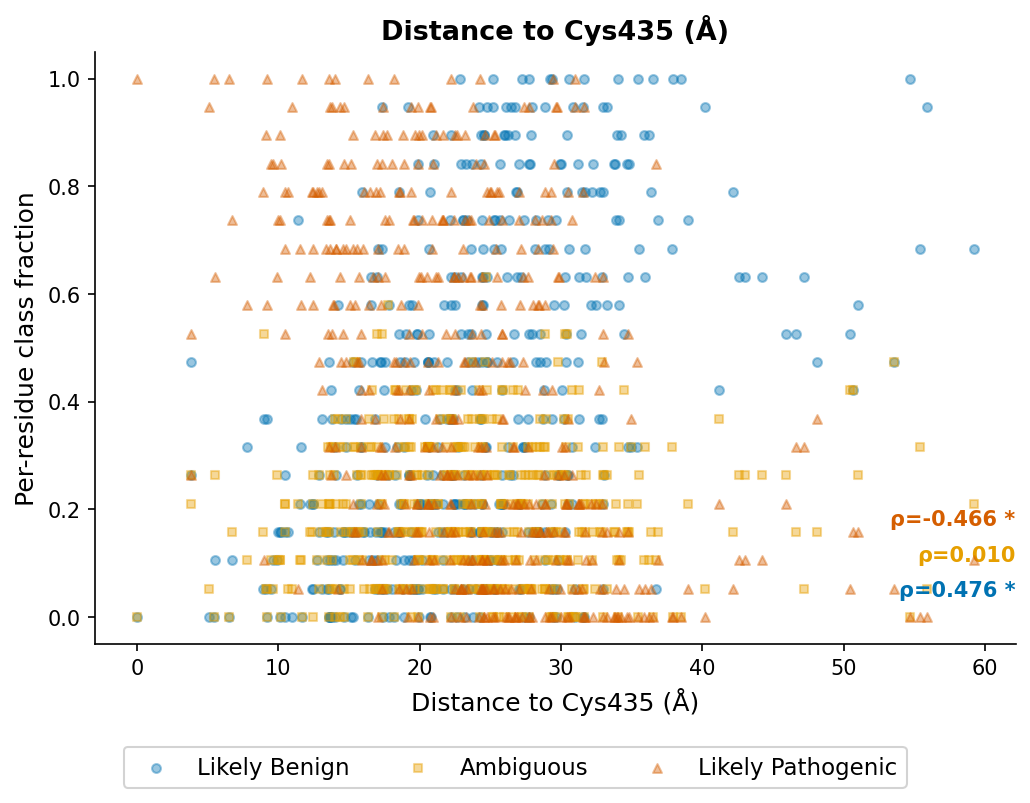

Spearman correlation (per-residue fraction vs. distance):

  Cys435:
    likely_benign              ρ=+0.476  p=4.724e-29
    ambiguous                  ρ=+0.010  p=8.233e-01
    likely_pathogenic          ρ=-0.466  p=1.132e-27



In [18]:
df_valid = cyp2c9_dist.dropna(subset=['dist_heme'])

# ── Single-panel version: distance to binding-site only ─────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

plot_dist_fractions(ax, df_valid, 'dist_heme', 'Distance to binding-site (Cys435, Å)')
ax.set_title('Distance to binding-site (Cys435, Å)', fontweight='bold', pad=15)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, [l.replace('_', ' ').title() for l in labels],
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08),
           fontsize=11)
fig.suptitle('CYP2C9: variant class fraction by distance to binding-site',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

pos_stats = (
    cyp2c9_dist.groupby('position')['pathogenicity class']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)
pos_stats = pos_stats.merge(
    cyp2c9_dist[['position', 'dist_heme']].drop_duplicates(),
    on='position', how='left'
)
fig, ax = plt.subplots(figsize=(7, 5))
col = 'dist_heme'
xlabel = "Distance to Cys435 (Å)"

sub = pos_stats.dropna(subset=[col])
for cls, zord in zip(CLASS_ORDER, [1, 2, 3]):
    marker = {'likely_benign': 'o', 'ambiguous': 's', 'likely_pathogenic': '^'}[cls]
    if cls not in sub.columns:
        continue
    ax.scatter(sub[col], sub[cls], color=PALETTE[cls], alpha=0.4,
                s=18, marker=marker, label=cls.replace('_', ' ').title(), zorder=zord)
    rho, p = spearmanr(sub[col], sub[cls])
    star = ' *' if p < 0.05 else ''
    ax.annotate(f'ρ={rho:.3f}{star}',
                xy=(1.0, {'likely_benign': 0.08, 'ambiguous': 0.14, 'likely_pathogenic': 0.20}[cls]),
                xycoords='axes fraction', ha='right', fontsize=10,
                color=PALETTE[cls], fontweight='bold')

ax.set_xlabel(xlabel, fontsize=12)
ax.set_ylabel('Per-residue class fraction', fontsize=12)
ax.set_title(xlabel, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=11)
plt.tight_layout()
plt.show()

# ── Print Spearman summary ─────────────────────────────────────────────────────
print('Spearman correlation (per-residue fraction vs. distance):\n')
col = "dist_heme"
label = "Cys435"
sub = pos_stats.dropna(subset=[col])
print(f"  {label}:")
for cls in CLASS_ORDER:
    if cls not in sub.columns:
        continue
    rho, p = spearmanr(sub[col], sub[cls])
    print(f"    {cls:25s}  ρ={rho:+.3f}  p={p:.3e}")
print()

### 5. Conservation via ESM-2 masked marginal probability (CYP2C9)

ESM-2 masked marginal probability (MMP) for a substitution is log P(mutant | context) − log P(wild-type | context) from the ESM-2 language model. A **more negative** value means the model penalizes that substitution more heavily — the position is more evolutionarily constrained (conserved). The per-position score is the **mean MMP across all 19 missense substitutions** at that position.

**Hypothesis:** ambiguous variants sit at positions of intermediate constraint — more conserved than benign but less conserved than pathogenic.

/tmp/ipykernel_3111/2498384342.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='pathogenicity class', y='mean_mmp',


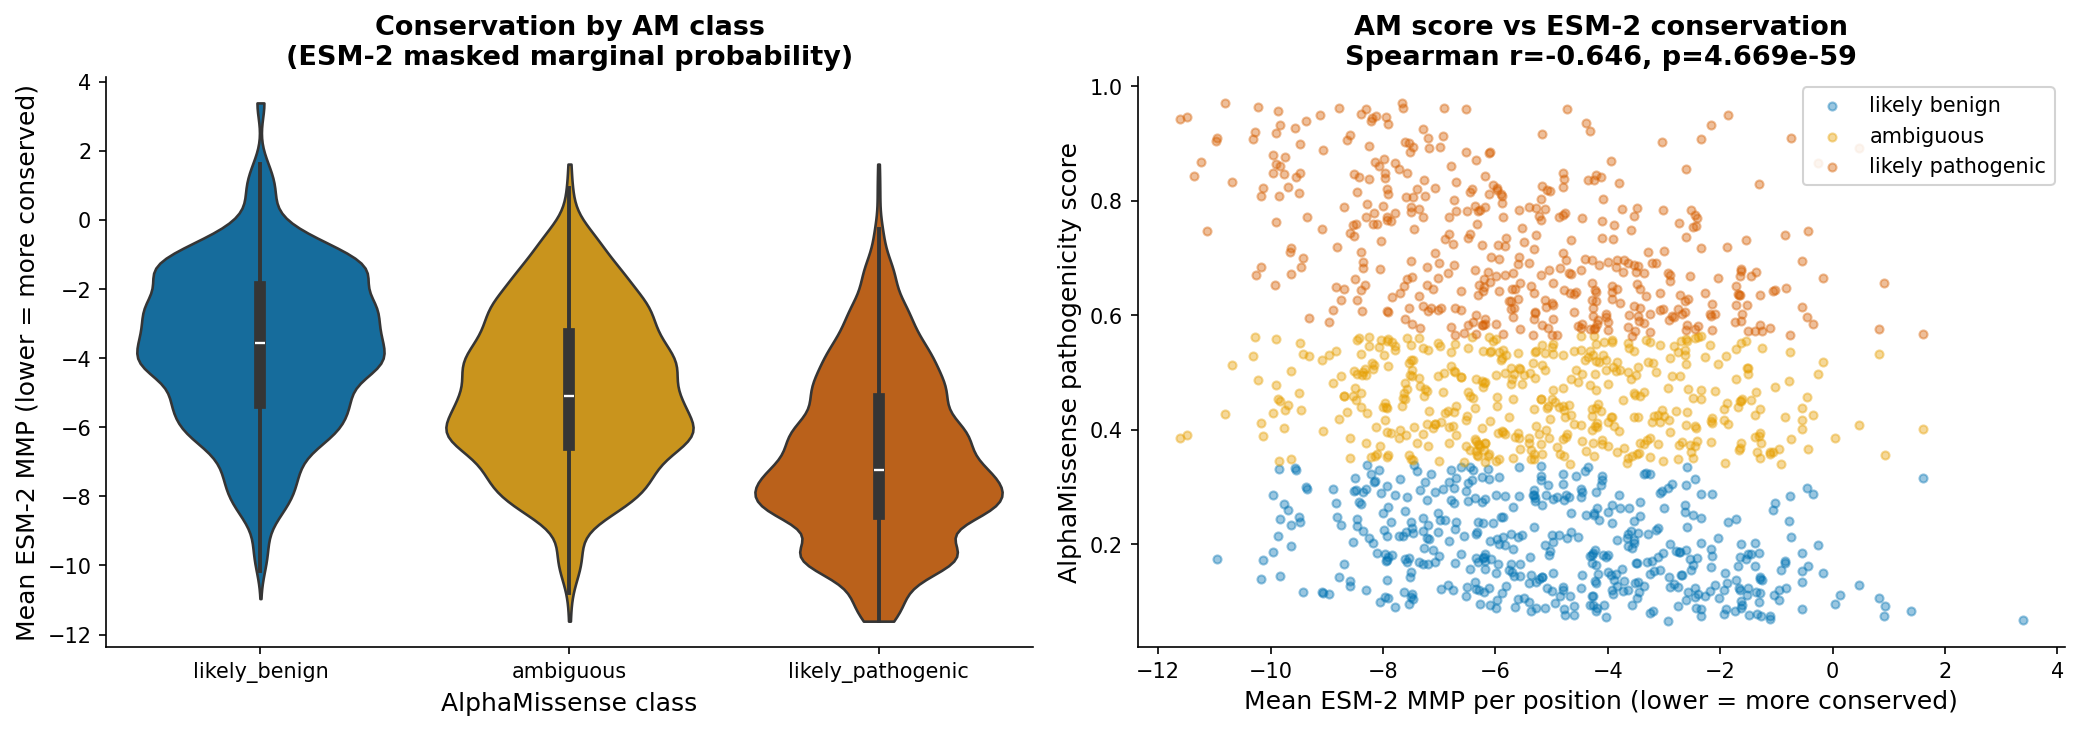

Mean ESM-2 MMP by AM class (per-variant, CYP2C9):

                     median   mean
pathogenicity class               
ambiguous            -5.109 -4.934
likely_benign        -3.562 -3.694
likely_pathogenic    -7.248 -6.881

Kruskal–Wallis: H=2550.785, p=0.000e+00
  likely_benign vs ambiguous: p_Bonf=9.504e-73
  likely_pathogenic vs ambiguous: p_Bonf=8.487e-160
  likely_benign vs likely_pathogenic: p_Bonf=0.000e+00


In [19]:
with open(f'{DATA_DIR}/masked_marginal_prob.json') as f:
    mmp_raw = json.load(f)

# Aggregate to per-position: mean MMP across all missense substitutions
pos_scores = {}
for key, val in mmp_raw.items():
    if '=' in key:
        continue  # skip synonymous
    m = re.match(r'P11712_[A-Za-z]+(\d+)[A-Za-z]+', key)
    if m:
        pos_scores.setdefault(int(m.group(1)), []).append(val)

pos_mean_mmp = {p: np.mean(v) for p, v in pos_scores.items()}

cyp2c9_cons = cyp2c9.copy()
cyp2c9_cons['mean_mmp'] = cyp2c9_cons['position'].map(pos_mean_mmp)

# ── Violin plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution per AM class
ax = axes[0]
plot_data = cyp2c9_cons[cyp2c9_cons['mean_mmp'].notna()]
sns.violinplot(data=plot_data, x='pathogenicity class', y='mean_mmp',
               order=CLASS_ORDER, palette=PALETTE, ax=ax, inner='box', cut=0)
ax.set_xlabel('AlphaMissense class', fontsize=12)
ax.set_ylabel('Mean ESM-2 MMP (lower = more conserved)', fontsize=12)
ax.set_title('Conservation by AM class\n(ESM-2 masked marginal probability)', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: scatter of mean MMP vs AM pathogenicity score
ax = axes[1]
for cls in CLASS_ORDER:
    sub = plot_data[plot_data['pathogenicity class'] == cls].drop_duplicates('position')
    ax.scatter(sub['mean_mmp'], sub['pathogenicity score'],
               color=PALETTE[cls], alpha=0.4, s=15, label=cls.replace('_', ' '), rasterized=True)

r, p = stats.spearmanr(plot_data.drop_duplicates('position')['mean_mmp'],
                        plot_data.drop_duplicates('position')['pathogenicity score'])
ax.set_xlabel('Mean ESM-2 MMP per position (lower = more conserved)', fontsize=12)
ax.set_ylabel('AlphaMissense pathogenicity score', fontsize=12)
ax.set_title(f'AM score vs ESM-2 conservation\nSpearman r={r:.3f}, p={p:.3e}', fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ── Statistics ────────────────────────────────────────────────────────────────
print('Mean ESM-2 MMP by AM class (per-variant, CYP2C9):\n')
print(cyp2c9_cons.groupby('pathogenicity class')['mean_mmp']
      .agg(['median', 'mean']).round(3).to_string())

groups = [cyp2c9_cons.loc[cyp2c9_cons['pathogenicity class'] == cls, 'mean_mmp'].dropna()
          for cls in CLASS_ORDER]
h, p_kw = kruskal(*groups)
print(f'\nKruskal–Wallis: H={h:.3f}, p={p_kw:.3e}')

pairs = [('likely_benign','ambiguous'), ('likely_pathogenic','ambiguous'),
         ('likely_benign','likely_pathogenic')]
raw_p = []
for c1, c2 in pairs:
    g1 = cyp2c9_cons.loc[cyp2c9_cons['pathogenicity class'] == c1, 'mean_mmp'].dropna()
    g2 = cyp2c9_cons.loc[cyp2c9_cons['pathogenicity class'] == c2, 'mean_mmp'].dropna()
    _, p = mannwhitneyu(g1, g2, alternative='two-sided')
    raw_p.append(p)
_, p_bonf, _, _ = multipletests(raw_p, method='bonferroni')
for (c1, c2), p_adj in zip(pairs, p_bonf):
    print(f'  {c1} vs {c2}: p_Bonf={p_adj:.3e}')